In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# --------------------- Import VQNiche ---------------------
from vqniche.utils.parse_test_configs import *
from vqniche.initializers.initialize import *
from vqniche.utils.type_conversions import *
from vqniche.plotting import *
from vqniche.metrics import pearson_correlation

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [3]:
# --------------------- Import Libraries ---------------------
import os
import copy
import sys
import yaml
import pickle
from pathlib import Path
from dataclasses import dataclass

import scanpy as sc
import anndata as ad
import squidpy as sq

import numpy as np
import networkx as nx
import scipy.sparse as sp
from scipy.stats import pearsonr

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import pytorch_lightning as pl
import torch_geometric.transforms as T
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj
from torch_geometric.loader import DataLoader as BatchBuilder

# --------------------- Display Settings ---------------------
# display setting all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Final Plots

In [4]:
xhs1021_15b_1p_3_test_patch_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1021-15b_1p/standalone/VQNiche/batch=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]/spatial_n_neighs_8/wandb/offline-run-20250924_162326-o5u8dpcl/files/user_specified_config.yaml")
with open(xhs1021_15b_1p_3_test_patch_file, 'r') as f:
    xhs1021_15b_1p_3_test_patch_cfg = yaml.safe_load(f)

In [5]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhs1021_15b_1p_3_test_patch_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1021_15b_1p_3_test_patch_data_batch = initialize_databatch(
    config=xhs1021_15b_1p_3_test_patch_cfg,
    dataset_blob=dataset_blob
)

# --------------------- Dataloader ---------------------
datamodule_batch = initialize_datamodule(
                        config=xhs1021_15b_1p_3_test_patch_cfg,
                        data=xhs1021_15b_1p_3_test_patch_data_batch,

                    )


Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting secti

In [6]:
n_test_cells = 0
flag = 1
for batch in datamodule_batch.test_dataloader():
    n_test_cells += batch.batch_size
    if flag:
        print(batch.adata_batch_ids[:5])
        print(batch.input_id[:5])
        flag = 0
    
print(n_test_cells)

tensor([0, 0, 0, 0, 0])
tensor([ 0,  5, 14, 18, 37])
27984


In [7]:
predict_fname = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1021-15b_1p/standalone/VQNiche/batch=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]/spatial_n_neighs_8/wandb/offline-run-20250924_162326-o5u8dpcl/results/epoch=3-train_pearson_1hop_nbr=0.74/predict_adata.pkl"
with open(predict_fname, "rb") as f:
    adata = pickle.load(f)
adata

AnnData object with n_obs × n_vars = 279849 × 1000
    obs: 'cell_types', 'adata_batch_ids'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'

In [8]:
import numpy as np
import pandas as pd

def _to_numpy(x):
    try:
        import torch
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

def build_test_index(datamodule_batch):
    ids = []
    for batch in datamodule_batch.test_dataloader():
        if not hasattr(batch, "input_id"):
            raise ValueError("Batch missing `input_id`; can't map back to AnnData rows.")
        ids.append(batch.input_id.detach().cpu().numpy())
    return np.unique(np.concatenate(ids).astype(np.int64))

def _slice_uns_and_add_to_obs(adata_src, adata_dst, key, prefix):
    """Slice adata_src.uns[key] on the selected rows and add columns to adata_dst.obs."""
    if key not in adata_src.uns:
        return  # silently skip if missing
    arr = _to_numpy(adata_src.uns[key])
    if arr.shape[0] != adata_src.n_obs:
        raise ValueError(f"uns['{key}'] first dim {arr.shape[0]} != AnnData rows {adata_src.n_obs}")

    # take only the rows that remain in adata_dst (same order as adata_dst.obs)
    # adata_dst was created by adata[test_idx].copy(), so obs_names map to those rows
    # we recover their original integer positions via .obs['_orig_indices'] if present,
    # otherwise rely on the selection having been done by position (recommended).
    sel = adata_dst.obs_names  # index alignment
    # when sliced by position, adata_dst.X rows correspond to the same order as test_idx
    # so we can just slice by range(len(adata_dst))
    arr_sel = arr[adata_dst.obs.index.to_numpy().astype(int) \
                  if adata_dst.obs.index.dtype.kind in "iu" else
                  np.arange(adata_dst.n_obs)]

    if arr_sel.ndim == 1:
        df = pd.DataFrame({f"{prefix}": arr_sel}, index=adata_dst.obs_names)
    elif arr_sel.ndim == 2:
        n_genes = arr_sel.shape[1]
        cols = [f"{prefix}_gene_{i}" for i in range(n_genes)]
        df = pd.DataFrame(arr_sel, index=adata_dst.obs_names, columns=cols)
    else:
        raise ValueError(f"uns['{key}'] has ndim={arr_sel.ndim}; expected 1D or 2D (n_cells x n_features).")

    adata_dst.obs = adata_dst.obs.join(df)

def adata_keep_test_cells_and_update_uns(
    adata,
    test_idx,
    uns_keys=("X", "X_hat", "X_nbr", "X_hat_nbr"),
    add_all_to_obs=True,
    prefixes=None
):
    """
    Subset AnnData to test cells, slice matching rows in .uns arrays,
    and (optionally) add each array as columns in obs with prefixes.

    prefixes: dict mapping uns key -> prefix, defaults to:
        {"X": "X", "X_hat": "Xhat", "X_nbr": "Xnbr", "X_hat_nbr": "Xhat_nbr"}
    """
    adata_test = adata[test_idx].copy()

    # default prefixes
    if prefixes is None:
        prefixes = {"X": "X", "X_hat": "Xhat", "X_nbr": "Xnbr", "X_hat_nbr": "Xhat_nbr"}

    # slice uns arrays to selected rows
    for k in uns_keys:
        if k in adata.uns:
            arr = _to_numpy(adata.uns[k])
            if arr.shape[0] != adata.n_obs:
                raise ValueError(f"uns['{k}'] first dim {arr.shape[0]} != AnnData rows {adata.n_obs}")
            adata_test.uns[k] = arr[test_idx]

    # add to obs
    if add_all_to_obs:
        for k in uns_keys:
            _slice_uns_and_add_to_obs(adata, adata_test, k, prefixes.get(k, k))

    return adata_test

In [9]:
# ---- Usage ----
test_idx = build_test_index(datamodule_batch)
adata_test = adata_keep_test_cells_and_update_uns(
    adata, test_idx,
    uns_keys=("X", "X_hat", "X_nbr", "X_hat_nbr", "Indices"),
    prefixes={"X":"X", "X_hat":"Xhat", "X_nbr":"X_nbr", "X_hat_nbr":"X_hat_nbr", "Indices":"Token"}
)

In [10]:
adata_test.obs.shape

(27984, 4003)

In [11]:
adata_test.obs['adata_batch_ids'].unique()
adata_test.obs['Z_level'] = adata_test.obs['adata_batch_ids']
df = adata_test.obs

In [12]:
adata_test.obs.shape

(27984, 4004)

In [13]:
df.columns[:5]

Index(['cell_types', 'adata_batch_ids', 'X_gene_0', 'X_gene_1', 'X_gene_2'], dtype='object')

[summary] paired=1000; ranked=1000; groups=[10, 20, 30, 40, 50]; rows=65; any_valid=True


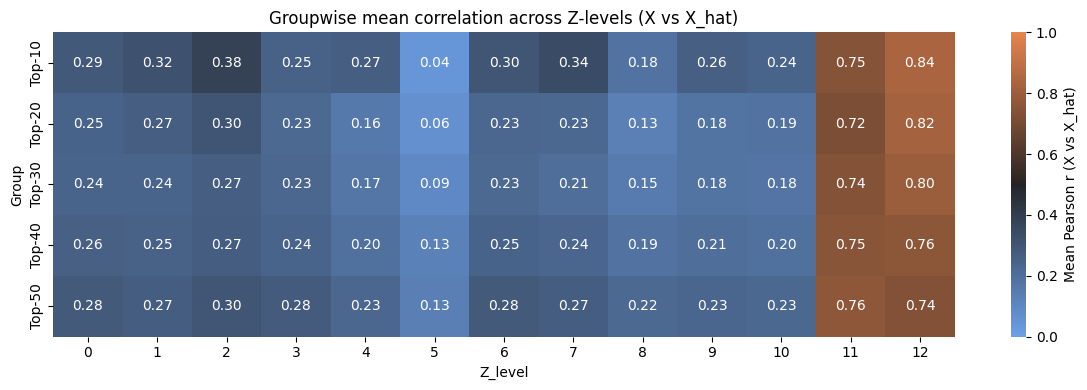

In [14]:
import re
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

def safe_pearson(x, y):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 2 or np.all(x == x[0]) or np.all(y == y[0]):
        return np.nan
    r, _ = pearsonr(x, y)
    return r

# --- detect and map X / X_hat columns (robust to naming) ---
def build_family(df, family: str):
    """
    family in {"X", "X_hat"}.
    Returns (mapping id->colname, order_list) where id can be numeric or any suffix.
    Matches patterns like:
      X_gene_123, X_123, X__123, X_gene_BRCA1 (then id='BRCA1')
      X_hat_gene_123, X_hat_123, X_hat__123, X_hat_gene_BRCA1
    """
    if family == "X":
        regexes = [
            re.compile(r'^X(?:_gene)?__?(\d+)$'),  # numeric id
            re.compile(r'^X(?:_gene)?__?(.+)$'),   # any suffix id
        ]
    else:  # X_hat
        regexes = [
            re.compile(r'^X_hat(?:_gene)?__?(\d+)$'),
            re.compile(r'^X_hat(?:_gene)?__?(.+)$'),
        ]
    mapping, order = {}, []
    for col in df.columns:
        for rx in regexes:
            m = rx.match(col)
            if m:
                gid = m.group(1)
                # only take first match per column
                if gid not in mapping:  # prefer first seen
                    mapping[gid] = col
                order.append(col)
                break
    return mapping, order

x_map, x_order   = build_family(df, "X")
xh_map, xh_order = build_family(df, "X_hat")

def _natkey(s):
    return [int(t) if t.isdigit() else t for t in re.split(r'(\d+)', s)]

# IDs that appear in both families
common_ids = sorted(set(x_map.keys()) & set(xh_map.keys()),
                    key=lambda s: (0, int(s)) if s.isdigit() else (1, s))

# Pair columns either by common id, or (fallback) by ordered position
if common_ids:
    pairs = [(gid, x_map[gid], xh_map[gid]) for gid in common_ids]
else:
    if len(x_order) == 0 or len(xh_order) == 0:
        raise ValueError("Couldn't find any X_* or X_hat_* columns.")
    if len(x_order) != len(xh_order):
        raise ValueError("Column count mismatch between X_* and X_hat_*; cannot pair by order.")
    x_cols  = sorted(x_order,  key=_natkey)
    xh_cols = sorted(xh_order, key=_natkey)
    pairs = [(f"pos{i}", xc, xhc) for i, (xc, xhc) in enumerate(zip(x_cols, xh_cols))]

# --- 1) GLOBAL per-gene correlation (rank genes) ---
global_corr = [(gid, safe_pearson(df[xc], df[xhc])) for gid, xc, xhc in pairs]
global_corr_df = (pd.DataFrame(global_corr, columns=["gene_id", "corr"])
                    .dropna()
                    .sort_values("corr", ascending=False))
if global_corr_df.empty:
    raise ValueError("All global correlations are NaN (likely constant vectors or insufficient data).")

# --- 2) Define Top-10/20/30/40/50 groups (only sizes <= available) ---
requested = [10, 20, 30, 40, 50]
# requested = [50, 100, 150, 200, 250]
available = len(global_corr_df)
group_sizes = [k for k in requested if k <= available] or [available]
groups = {k: global_corr_df.head(k)["gene_id"].astype(str).tolist() for k in group_sizes}

# helper: map gene_id back to column names
id_to_cols = {str(gid): (xc, xhc) for gid, xc, xhc in pairs}

# --- 3) Per-Z_level aggregation within each group ---
z_levels = (pd.to_numeric(df["Z_level"], errors="coerce")
            .dropna().sort_values().unique())

rows = []
for z in z_levels:
    sub = df[df["Z_level"] == z]
    for k, gene_ids in groups.items():
        rs = []
        for gid in gene_ids:
            xc, xhc = id_to_cols[gid]
            rs.append(safe_pearson(sub[xc], sub[xhc]))
        rs = np.asarray(rs, float)
        finite = np.isfinite(rs)
        rows.append({
            "Z_level": z,
            "Group": f"Top-{k}",
            "mean_r": np.nan if not finite.any() else float(np.nanmean(rs)),
            "median_r": np.nan if not finite.any() else float(np.nanmedian(rs)),
            "n_valid": int(finite.sum())
        })

res = pd.DataFrame(rows)
print(f"[summary] paired={len(pairs)}; ranked={available}; groups={list(groups.keys())}; "
      f"rows={len(res)}; any_valid={np.isfinite(res['mean_r']).any()}")

# --- 4) Plot (mean correlation) ---
# plt.figure(figsize=(10, 6))
# sns.lineplot(data=res, x="Z_level", y="mean_r", hue="Group", marker="o")
# plt.ylim(-1, 1)
# plt.ylabel("Mean Pearson r (X vs X_hat)")
# plt.title("Groupwise reconstruction correlation across Z-levels (X vs X_hat)")
# plt.tight_layout()
# plt.show()

# (Optional) median instead of mean:
# plt.figure(figsize=(10, 6))
# sns.lineplot(data=res, x="Z_level", y="median_r", hue="Group", marker="o")
# plt.ylim(-1, 1); plt.ylabel("Median Pearson r (X vs X_hat)"); plt.tight_layout(); plt.show()

# Pivot to Group × Z_level
heat = (
    res.pivot(index="Group", columns="Z_level", values="mean_r")
      .reindex(sorted(res["Z_level"].unique()), axis=1)  # sort Z-levels
      .sort_index()                                       # sort groups
)

plt.figure(figsize=(12, 4))
sns.heatmap(
    heat, vmin=0, vmax=1, cmap=sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True),
    annot=True, fmt=".2f",
    cbar_kws={"label": "Mean Pearson r (X vs X_hat)"}
)
plt.title("Groupwise mean correlation across Z-levels (X vs X_hat)")
plt.xlabel("Z_level")
plt.ylabel("Group")
plt.tight_layout()
plt.show()

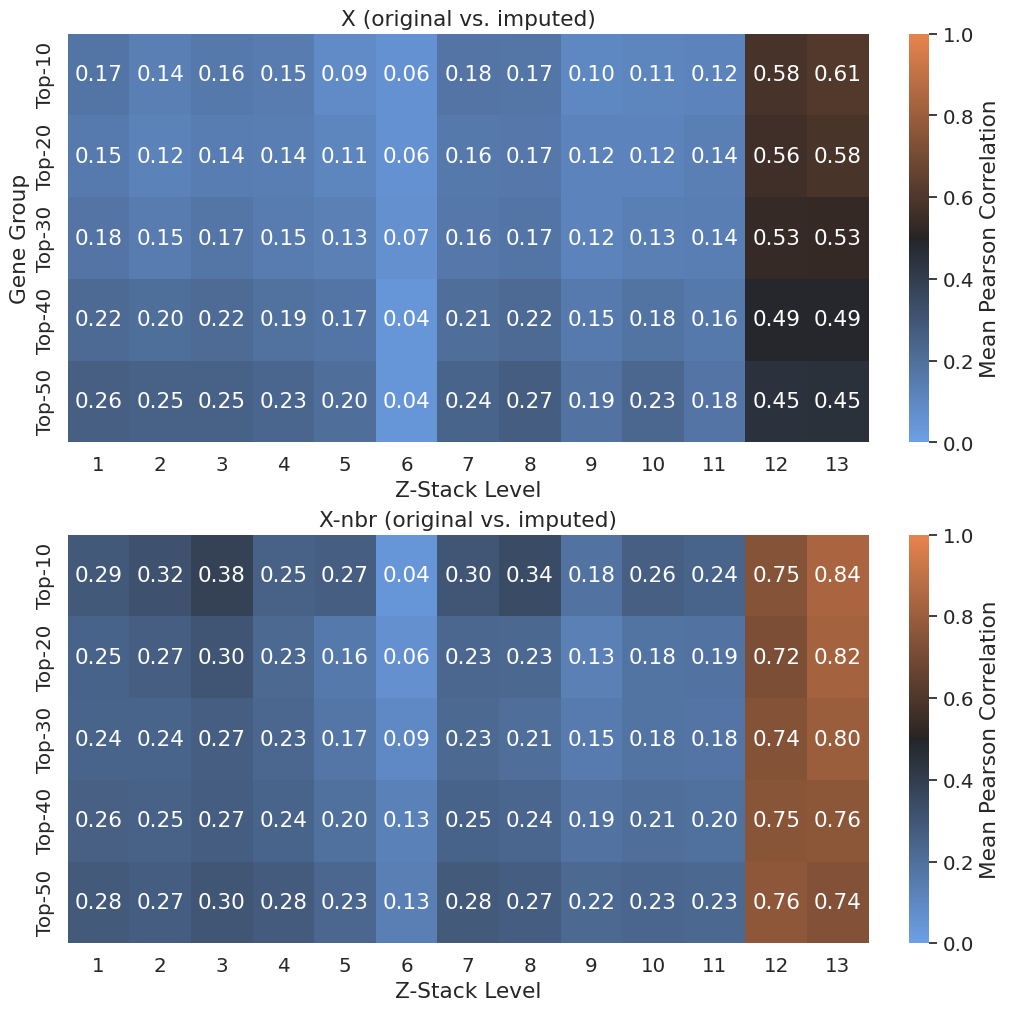

In [78]:
import re
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt


# Setting the font size by 2.5 
sns.set(rc = {'figure.figsize':(10,10)})
sns.set(font_scale=1.3)

# ---------- helpers ----------
def safe_pearson(x, y):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 2 or np.all(x == x[0]) or np.all(y == y[0]):
        return np.nan
    r, _ = pearsonr(x, y)
    return r

def detect_prefix(all_cols, candidates):
    for p in candidates:
        if any(c.startswith(p) for c in all_cols):
            return p
    return None

def natural_sort(cols):
    return sorted(cols, key=lambda s: [int(t) if t.isdigit() else t for t in re.split(r'(\d+)', s)])

def compute_groupwise_res(df, familyA_candidates, familyB_candidates, requested_groups=(10,20,30, 40, 50), z_col="Z_level"):
    all_cols = df.columns.tolist()
    PA = detect_prefix(all_cols, familyA_candidates)
    PB = detect_prefix(all_cols, familyB_candidates)
    if PA is None or PB is None:
        raise ValueError(f"Could not find columns for prefixes {familyA_candidates} or {familyB_candidates}")

    # map id -> col for each family (numeric id preferred, else any suffix)
    rxA_num = re.compile(rf"^{re.escape(PA)}(\d+)$")
    rxB_num = re.compile(rf"^{re.escape(PB)}(\d+)$")
    rxA_any = re.compile(rf"^{re.escape(PA)}(.+)$")
    rxB_any = re.compile(rf"^{re.escape(PB)}(.+)$")

    A_map, B_map = {}, {}
    A_order = [c for c in all_cols if c.startswith(PA)]
    B_order = [c for c in all_cols if c.startswith(PB)]

    for c in A_order:
        m = rxA_num.match(c) or rxA_any.match(c)
        if m: A_map[m.group(1)] = c
    for c in B_order:
        m = rxB_num.match(c) or rxB_any.match(c)
        if m: B_map[m.group(1)] = c

    common_ids = sorted(set(A_map.keys()) & set(B_map.keys()), key=lambda s: (0, int(s)) if s.isdigit() else (1, s))

    if common_ids:
        pairs = [(gid, A_map[gid], B_map[gid]) for gid in common_ids]
    else:
        # fallback: pair by order (after natural sort)
        A_sorted = natural_sort(A_order)
        B_sorted = natural_sort(B_order)
        if len(A_sorted) != len(B_sorted):
            raise ValueError("Column count mismatch; cannot pair by order.")
        pairs = [(f"pos{i}", a, b) for i, (a, b) in enumerate(zip(A_sorted, B_sorted))]

    # global ranking
    global_corr = [(gid, safe_pearson(df[a], df[b])) for gid, a, b in pairs]
    global_corr_df = pd.DataFrame(global_corr, columns=["gene_id", "corr"]).dropna().sort_values("corr", ascending=False)
    if global_corr_df.empty:
        raise ValueError("All global correlations are NaN (constant vectors or insufficient data).")

    available = len(global_corr_df)
    group_sizes = [k for k in requested_groups if k <= available] or [available]
    groups = {k: global_corr_df.head(k)["gene_id"].astype(str).tolist() for k in group_sizes}
    id_to_cols = {str(gid): (a, b) for gid, a, b in pairs}

    # per-Z level aggregation
    z_levels = (pd.to_numeric(df[z_col], errors="coerce").dropna().sort_values().unique())
    rows = []
    for z in z_levels:
        sub = df[df[z_col] == z]
        for k in group_sizes:
            genes = groups[k]
            rs = []
            for gid in genes:
                a, b = id_to_cols[gid]
                rs.append(safe_pearson(sub[a], sub[b]))
            rs = np.asarray(rs, float)
            finite = np.isfinite(rs)
            rows.append({
                "Z_level": z,
                "Group": f"Top-{k}",
                "mean_r": np.nan if not finite.any() else float(np.nanmean(rs)),
                "median_r": np.nan if not finite.any() else float(np.nanmedian(rs)),
                "n_valid": int(finite.sum())
            })
    res = pd.DataFrame(rows)
    return res

# ---------- compute both: X vs X_hat AND X_nbr vs X_hat_nbr ----------
res_x = compute_groupwise_res(
    df,
    familyA_candidates=["X_gene_", "X_", "X__"],
    familyB_candidates=["X_hat_gene_", "X_hat_", "X_hat__"]
)
res_nbr = compute_groupwise_res(
    df,
    familyA_candidates=["X_nbr_gene_", "X_nbr_", "X_nbr__"],
    familyB_candidates=["X_hat_nbr_gene_", "X_hat_nbr_", "X_hat_nbr__"]
)

# ---------- build heatmaps (0..1 scale) ----------
def make_heat(res):
    heat = (res.pivot(index="Group", columns="Z_level", values="mean_r"))
    # sort groups by their numeric k (Top-10, Top-20, ...)
    heat = heat.reindex(sorted(heat.index, key=lambda s: int(str(s).split('-')[-1])))
    # sort Z-levels numerically
    heat = heat.reindex(sorted(heat.columns), axis=1)
    # clip to [0, 1] for display (negatives shown as 0)
    return heat.clip(lower=0, upper=1)

heat_x = make_heat(res_x)
heat_nbr = make_heat(res_nbr)

# ---------- plot side-by-side ----------
# fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True, sharey=True)
# sns.heatmap(
#     heat_x, vmin=0, vmax=1, cmap=sns.color_palette("Blues", as_cmap=True), annot=True, fmt=".2f",
#     cbar_kws={"label": "Mean Pearson r"}, ax=axes[0]
# )
# axes[0].set_title("X vs X_hat (groupwise mean r)")
# axes[0].set_xlabel("Z_level"); axes[0].set_ylabel("Group")

# sns.heatmap(
#     heat_nbr, vmin=0, vmax=1, cmap=sns.color_palette("Blues", as_cmap=True), annot=True, fmt=".2f",
#     cbar_kws={"label": "Mean Pearson r"}, ax=axes[1]
# )
# axes[1].set_title("X_nbr vs X_hat_nbr (groupwise mean r)")
# axes[1].set_xlabel("Z-Stack Level"); axes[1].set_ylabel("")

# --- build 1-indexed x tick labels for each heatmap ---
xlabels_x   = [int(z) + 1 for z in heat_x.columns]
xlabels_nbr = [int(z) + 1 for z in heat_nbr.columns]

fig, axes = plt.subplots(2, 1, figsize=(10, 10), constrained_layout=True, sharey=True)

sns.heatmap(
    heat_x, vmin=0, vmax=1, cmap=sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True),
    annot=True, fmt=".2f", xticklabels=xlabels_x, cbar=True,
    cbar_kws={"label": "Mean Pearson Correlation"}, ax=axes[0]
)
axes[0].set_title("X (original vs. imputed)")
axes[0].set_xlabel("Z-Stack Level")
axes[0].set_ylabel("Gene Group")

sns.heatmap(
    heat_nbr, vmin=0, vmax=1, cmap=sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True),
    annot=True, fmt=".2f", xticklabels=xlabels_nbr,
    cbar_kws={"label": "Mean Pearson Correlation"}, ax=axes[1]
)
axes[1].set_title("X-nbr (original vs. imputed)")
axes[1].set_xlabel("Z-Stack Level")
axes[1].set_ylabel("")
axes[1].tick_params(left=False)

# plt.suptitle()
# rotate y-tick labels by 15 degrees
# for ax in axes:
    # ax.set_yticklabels(ax.get_yticklabels(), rotation=15)
    
plt.savefig("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/plots/tasks/Z-stack_vs_Gene-Group_PC.pdf")


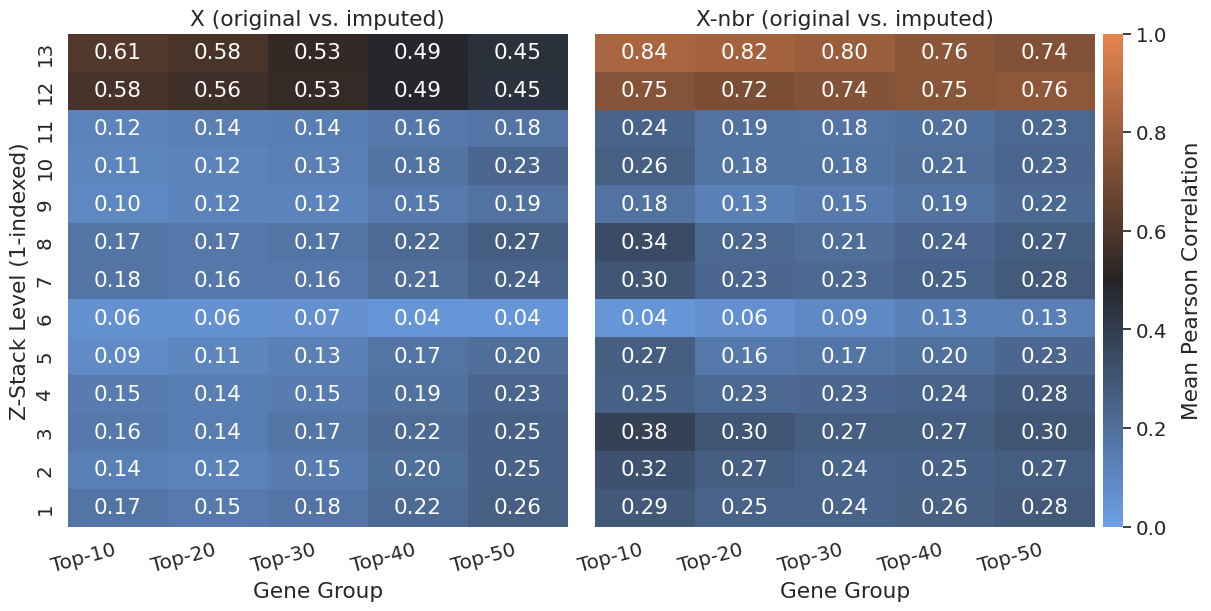

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Setting the font size by 2.5 
sns.set(rc = {'figure.figsize':(5,5)})
sns.set(font_scale=1.3)

# --- transpose so rows = Z-levels, cols = groups ---
vx   = heat_x.T   # index = Z_level, columns = Group
vnbr = heat_nbr.T

# 1-index Z-level labels
ylabels_x   = [int(pd.to_numeric(z)) + 1 for z in vx.index]
ylabels_nbr = [int(pd.to_numeric(z)) + 1 for z in vnbr.index]  # should match ylabels_x

# --- shared colormap & limits ---
cmap = cmap=sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True)
vmin, vmax = 0, 1

# --- figure with shared colorbar axis on the right ---
fig = plt.figure(figsize=(12, 6), layout='constrained')
gs  = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.04])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])  # shared colorbar axis

# Left panel: X vs X_hat (vertical Z)
sns.heatmap(
    vx, vmin=vmin, vmax=vmax, cmap=cmap,
    annot=True, fmt=".2f",
    yticklabels=ylabels_x, xticklabels=True,
    cbar=False, ax=ax1
)
ax1.set_title("X (original vs. imputed)")
ax1.set_xlabel("Gene Group")
ax1.set_ylabel("Z-Stack Level (1-indexed)")
ax1.invert_yaxis()  # make 1 at the bottom

# Right panel: X_nbr vs X_hat_nbr (vertical Z)
hm = sns.heatmap(
    vnbr, vmin=vmin, vmax=vmax, cmap=cmap,
    annot=True, fmt=".2f",
    yticklabels=ylabels_nbr, xticklabels=True,
    cbar=True, cbar_ax=cax, ax=ax2
)
ax2.set_title("X-nbr (original vs. imputed)")
ax2.set_xlabel("Gene Group")
ax2.set_ylabel("")
ax2.invert_yaxis()  # make 1 at the bottom

# Shared colorbar label
cax.set_ylabel("Mean Pearson Correlation", rotation=90, labelpad=10)

# (optional) slant x tick labels for readability
for i, ax in enumerate([ax1, ax2]):
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
    if i == 1:
        ax.set_yticklabels([], rotation=15, ha="right")

plt.show()

# Save, if you like:
fig.savefig("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/plots/tasks/Z-stack_vs_Gene-Group_PC.pdf", bbox_inches="tight")


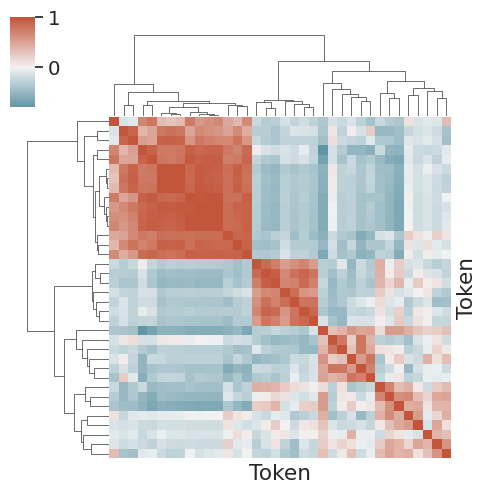

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# sns.set(rc = {'figure.figsize':(20,10)})

# Setting the font size by 2.5 
# sns.set(font_scale=1)

# --- config ---
top_k = 50           # number of tokens to visualize
corr_kind = "pearson"  # "pearson" or "spearman"

# --- 1) counts per (Z_level, Token) ---
tok = df[["Z_level", "Token"]].copy()
tok["Z_level"] = pd.to_numeric(tok["Z_level"], errors="coerce")
tok["Token"]   = pd.to_numeric(tok["Token"], errors="coerce")
tok = tok.dropna(subset=["Z_level","Token"])

counts = (
    tok.groupby(["Z_level", "Token"])
       .size()
       .unstack(fill_value=0)   # -> rows: Z_level, cols: Token
)

# --- 2) convert to proportions within each Z_level ---
prop = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

# --- 3) choose top_k tokens (by total count across all levels) ---
top_tokens = counts.sum(axis=0).nlargest(top_k).index
# top_tokens = prop.var(axis=0).nlargest(top_k).index

prop_top = prop[top_tokens]

# --- 4) token × token correlation across Z-levels ---
if corr_kind == "spearman":
    corr = prop_top.rank(axis=0).corr(method="pearson")  # Spearman via rank+Pearson
else:
    corr = prop_top.corr(method="pearson")

# --- 5) clustermap (co-occurrence similarity across Z-levels) ---
g = sns.clustermap(
    corr,
    cmap=sns.diverging_palette(220, 20, as_cmap=True), center=0,
    figsize=(5, 5),
    linewidths=0.0,
    xticklabels=False, yticklabels=False,
)
g.ax_heatmap.set_xlabel("Token")
g.ax_heatmap.set_ylabel("Token")

# title = f"Token co-occurrence across Z-levels (by mean PC)"
# g.fig.suptitle(title, y=0.99)          # place title near the top edge
# g.fig.subplots_adjust(top=0.88)        # push the heatmap down to add vertical space
# plt.show()

plt.savefig("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/plots/tasks/3D_token_co-occurrence.pdf")

/tmp/ipykernel_86894/1409658366.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(top_tokens))


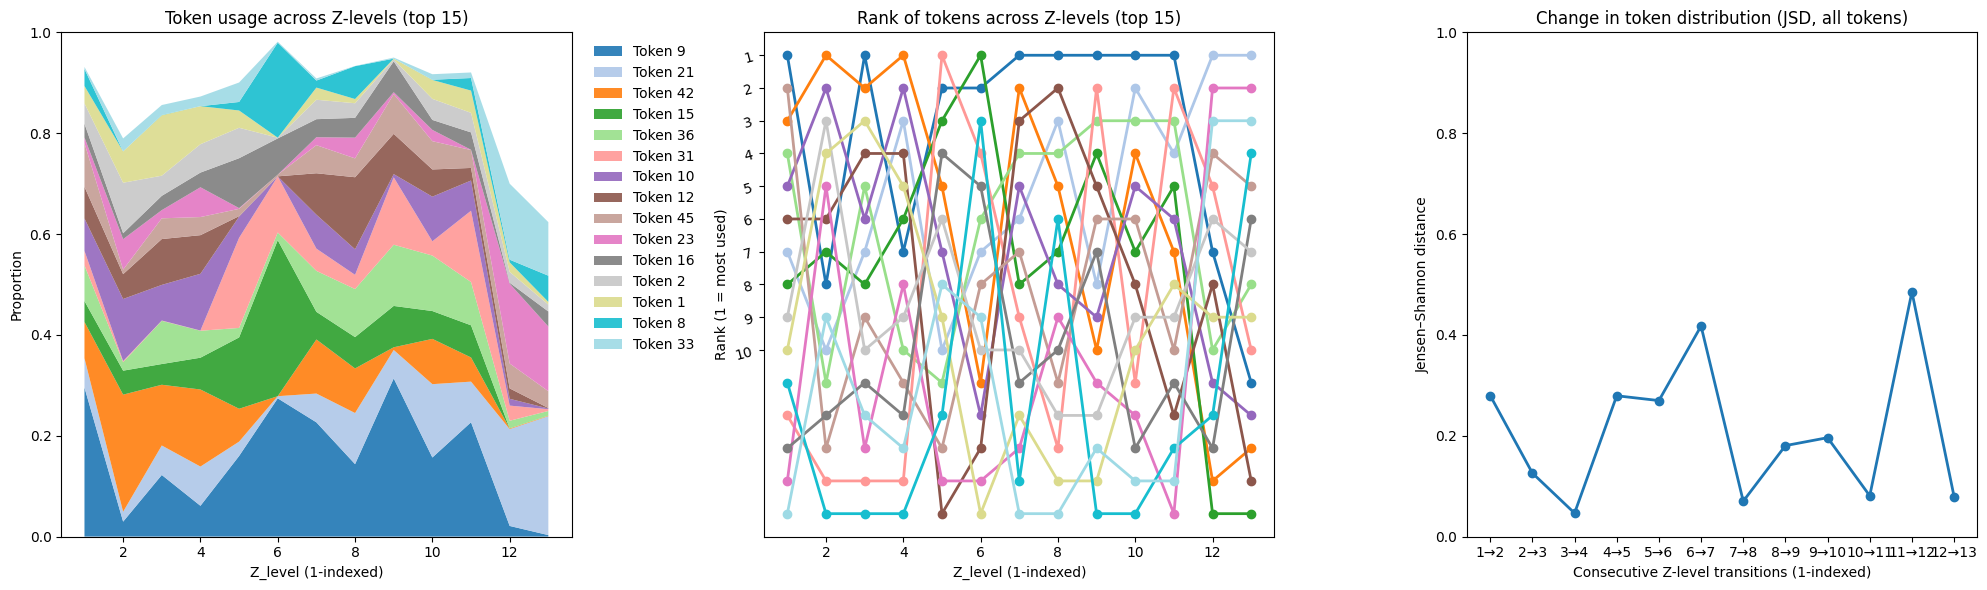

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_token_assignment_changes_with_divergence(df, top_k=15, jsd_top_only=False):
    """
    df must have columns: ['Z_level', 'Token'].
    - top_k: number of most frequent tokens to visualize in left + middle panels
    - jsd_top_only: if True, compute JSD using only the top_k tokens; otherwise use all tokens
    """
    tok = df[['Z_level', 'Token']].copy()
    tok['Z_level'] = pd.to_numeric(tok['Z_level'], errors='coerce')
    tok['Token']   = pd.to_numeric(tok['Token'], errors='coerce')
    tok = tok.dropna(subset=['Z_level','Token'])

    # counts per (Z_level, Token) -> rows: levels, cols: tokens
    counts = (tok.groupby(['Z_level','Token'])
                 .size()
                 .unstack(fill_value=0)
                 .sort_index())

    # proportions within each level
    row_sums = counts.sum(axis=1)
    prop = counts.div(row_sums.replace(0, np.nan), axis=0).fillna(0)

    # pick top_k tokens overall by total count
    avail = min(top_k, counts.shape[1])
    top_tokens = counts.sum(axis=0).nlargest(avail).index.tolist()

    # subset for display panels (area + bump)
    prop_top = prop[top_tokens]
    z_vals = prop_top.index.to_numpy()
    z_labels = (z_vals.astype(int) + 1).astype(int)  # 1-indexed display

    # colors
    cmap = plt.cm.get_cmap('tab20', len(top_tokens))
    colors = [cmap(i) for i in range(len(top_tokens))]

    # ------- helper: Jensen–Shannon divergence (base-2; in [0,1]) -------
    def js_divergence(p, q, base=2):
        p = np.asarray(p, float); q = np.asarray(q, float)
        ps, qs = p.sum(), q.sum()
        if ps <= 0 or qs <= 0:
            return np.nan
        p = p / ps; q = q / qs
        m = 0.5 * (p + q)
        def _kl(a, b):
            mask = a > 0
            return np.sum(a[mask] * (np.log(a[mask] / b[mask])))
        js = 0.5 * (_kl(p, m) + _kl(q, m))
        if base == 2:
            js /= np.log(2)
        elif base == 10:
            js /= np.log(10)
        return float(js)

    # choose matrix for JSD (all tokens or top_k)
    prop_for_jsd = prop_top if jsd_top_only else prop

    # compute JSD between consecutive levels
    jsd_vals = []
    for i in range(len(prop_for_jsd.index) - 1):
        p = prop_for_jsd.iloc[i].values
        q = prop_for_jsd.iloc[i+1].values
        jsd_vals.append(js_divergence(p, q, base=2))

    # x positions and labels for transitions (1-indexed)
    trans_pos = np.arange(1, len(z_labels))  # positions align with lower level index
    trans_labels = [f"{i}→{i+1}" for i in z_labels[:-1]]

    # --------- plotting: 3 panels ---------
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    # Panel 1: Stacked area (proportions)
    y = prop_top[top_tokens].T.values  # shape: n_tokens x n_levels
    axes[0].stackplot(z_labels, y, labels=[f"Token {t}" for t in top_tokens], colors=colors, alpha=0.9)
    axes[0].set_title(f"Token usage across Z-levels (top {avail})")
    axes[0].set_xlabel("Z_level (1-indexed)")
    axes[0].set_ylabel("Proportion")
    axes[0].set_ylim(0, 1)
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, ncol=1)

    # Panel 2: Bump chart (ranks)
    ranks = prop_top.rank(axis=1, ascending=False, method='first')
    for i, t in enumerate(top_tokens):
        axes[1].plot(z_labels, ranks[t].values, marker='o', linewidth=2, color=colors[i], label=f"Token {t}")
    axes[1].invert_yaxis()  # rank 1 at top
    axes[1].set_yticks(range(1, min(10, avail)+1))
    axes[1].set_title(f"Rank of tokens across Z-levels (top {avail})")
    axes[1].set_xlabel("Z_level (1-indexed)")
    axes[1].set_ylabel("Rank (1 = most used)")
    axes[1].set_yticklabels([str(t) for t in axes[1].get_yticks()], rotation=15)

    # Panel 3: JSD between consecutive levels
    axes[2].plot(trans_pos, jsd_vals, marker='o', linewidth=2)
    axes[2].set_xticks(trans_pos)
    axes[2].set_xticklabels(trans_labels, rotation=0)
    axes[2].set_ylim(0, 1)
    axes[2].set_title(f"Change in token distribution (JSD, {'top-'+str(avail) if jsd_top_only else 'all tokens'})")
    axes[2].set_xlabel("Consecutive Z-level transitions (1-indexed)")
    axes[2].set_ylabel("Jensen–Shannon distance")

    plt.tight_layout()
    plt.show()

# Example:
plot_token_assignment_changes_with_divergence(df, top_k=15, jsd_top_only=False)


In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- pick the gene set to show ------------------------------------
# Option A: genes that were "best" at least once (from df_best)
# df_best has columns ["Z_level","BestGene","BestCorr"] with BestGene like "Gene 123"
top_gene_ids = sorted({g.split()[-1] for g in df_best["BestGene"]})

# # Option B (alternative): the top-5-by-mean in X from earlier
# x_cols = [c for c in df.columns if c.startswith("X_") and not c.startswith(("X_hat_","X_nbr_","X_hat_nbr_"))]
# top5 = df[x_cols].mean(0).nlargest(5)
# top_gene_ids = [c.split("_")[-1] for c in top5.index]

# --- compute correlations for these genes across all Z-levels -----
z_levels = sorted(df["Z_level"].unique())
heat = pd.DataFrame(index=[f"Gene {g}" for g in top_gene_ids], columns=z_levels, dtype=float)

for gid in top_gene_ids:
    x_col, xh_col = f"X_{gid}", f"X_hat_{gid}"
    if xh_col not in df.columns or x_col not in df.columns:
        continue
    for z in z_levels:
        block = df.loc[df["Z_level"] == z, [x_col, xh_col]].dropna()
        # need ≥2 points and non-constant to compute Pearson r
        if len(block) >= 2 and not np.all(block[x_col].values == block[x_col].values[0]) \
                           and not np.all(block[xh_col].values == block[xh_col].values[0]):
            r, _ = pearsonr(block[x_col].values, block[xh_col].values)
        else:
            r = np.nan
        heat.loc[f"Gene {gid}", z] = r

# --- plot full heatmap --------------------------------------------
plt.figure(figsize=(12, 5))
sns.heatmap(
    heat.astype(float),
    annot=True, fmt=".2f",
    cmap="Spectral", vmin=0, vmax=1, center=0.1,
    cbar_kws={"label": "Pearson r (X vs X_hat)"}
)
plt.title("Per-gene reconstruction correlation across Z-levels")
plt.xlabel("Z_level")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()


NameError: name 'df_best' is not defined

# Dataset: Xenium Skin 3D (Human) | Sections: 1 to 15

In [5]:
import math
import matplotlib.pyplot as plt
import torch

def multiple_sections_train_val_test_splits(
        data_batch,
        height=5,
        width=6,
        title='Spatial Distribution of Train/Validation/Test Splits',
        xlim=None,
        ylim=None,
    ):
    colors = {'train': 'lightgrey', 'val': 'blue', 'test': 'red'}

    n_graphs = len(data_batch.adata_batch_id)
    n_rows = math.ceil(n_graphs/5)
    n_cols = min(n_graphs, 5)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols*width, n_rows*height),
        squeeze=False
    )

    use_ptr = hasattr(data_batch, 'ptr') and data_batch.ptr is not None

    # --- compute global coordinate ranges ---
    coords_all = data_batch.xy_coordinates.cpu()
    x_min, x_max = coords_all[:, 0].min().item(), coords_all[:, 0].max().item()
    y_min, y_max = coords_all[:, 1].min().item(), coords_all[:, 1].max().item()

    for i in range(n_graphs):
        # row, col = divmod(i, n_cols)
        # ax = axes[row, col]
        ax = axes.flatten()[i]

        if use_ptr:
            start = int(data_batch.ptr[i])
            end = int(data_batch.ptr[i+1])
            idx = torch.arange(start, end, device=data_batch.xy_coordinates.device)
        else:
            idx = (data_batch.batch == i).nonzero(as_tuple=True)[0]

        coords = data_batch.xy_coordinates[idx].cpu()
        train = data_batch.train_mask[idx].cpu()
        val = data_batch.val_mask[idx].cpu()
        test = data_batch.test_mask[idx].cpu()

        if train.any():
            ax.scatter(coords[train, 0], coords[train, 1], s=5, c=colors['train'], label='train')
        if val.any():
            ax.scatter(coords[val, 0], coords[val, 1], s=5, c=colors['val'], label='val')
        if test.any():
            ax.scatter(coords[test, 0], coords[test, 1], s=5, c=colors['test'], label='test')

        ax.set_title(f'Batch {data_batch.adata_batch_id[i]}')
        ax.set_aspect('equal')
        if xlim != -1:
            if xlim is None:
                xlim = (x_min, x_max)
            ax.set_xlim(xlim)
        if ylim != -1:
            if ylim is None:
                ylim = (y_min, y_max)
            ax.set_ylim(ylim)

        ax.set_xlabel("X coordinate")
        ax.set_ylabel("Y coordinate")

    # remove empty subplots if any
    for j in range(n_graphs, n_rows*n_cols):
        row, col = divmod(j, n_cols)
        fig.delaxes(axes[row, col])

    # Legend in the last axis used
    axes[(n_graphs-1)//n_cols, (n_graphs-1)%n_cols].legend(loc='lower right', frameon=False)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [7]:
xhs1021_15b_1p_3_test_patch_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1021-15b_1p_3-test-patch-split_vqniche_graphsage.yaml")
with open(xhs1021_15b_1p_3_test_patch_file, 'r') as f:
    xhs1021_15b_1p_3_test_patch_cfg = yaml.safe_load(f)

In [8]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhs1021_15b_1p_3_test_patch_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1021_15b_1p_3_test_patch_data_batch = initialize_databatch(
    config=xhs1021_15b_1p_3_test_patch_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting secti

## Visualize 3D

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
import torch

def _get_slice_indices(data_batch, i, use_ptr):
    if use_ptr:
        start = int(data_batch.ptr[i]); end = int(data_batch.ptr[i+1])
        return torch.arange(start, end, device=data_batch.xy_coordinates.device)
    return (data_batch.batch == i).nonzero(as_tuple=True)[0]

def stack_sections_3d_simple(
    data_batch,
    spacing_microns=60.0,
    title="3D stack of sections (aligned bbox, pulled-out highlights, with slide background)",
    s=1,
    alpha=0.7,
    highlight_sections_1based=(2,4,6,8),   # human indexing
    offset_factor=5,
    highlight_bbox_lw=2.0,
    normal_bbox_lw=1.0,
    normal_bbox_alpha=0.2,
    slide_facecolor=(0.95, 0.95, 0.95, 0.6)  # light grey, semi-transparent
):
    n_graphs = len(data_batch.adata_batch_id)
    use_ptr = hasattr(data_batch, 'ptr') and data_batch.ptr is not None

    # global extents (shared bounding box)
    coords_all = data_batch.xy_coordinates.cpu().numpy()
    gxmin, gxmax = coords_all[:, 0].min(), coords_all[:, 0].max()
    gymin, gymax = coords_all[:, 1].min(), coords_all[:, 1].max()
    gwidth = gxmax - gxmin
    dx = offset_factor * gwidth * 100

    highlights = set([h-1 for h in highlight_sections_1based if 1 <= h <= n_graphs])

    base_cmap = plt.cm.Oranges
    norm = plt.Normalize(vmin=0, vmax=n_graphs - 1)

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')

    # --- clean background ---
    ax.set_facecolor("white")
    ax.grid(False)
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.set_facecolor((1,1,1,1))
        axis.pane.set_edgecolor("w")

    for i in range(n_graphs):
        idx = _get_slice_indices(data_batch, i, use_ptr)
        coords = data_batch.xy_coordinates[idx].cpu().numpy()
        zval = i * spacing_microns
        z = np.full(coords.shape[0], zval, dtype=float)

        is_highlight = i in highlights
        x_shift = dx if is_highlight else 0.0

        coords_shifted = coords.copy()
        coords_shifted[:, 0] += x_shift
        color = base_cmap(norm(i))

        # --- add background panel ("slide") ---
        rect = [
            [gxmin + x_shift, gymin, zval],
            [gxmax + x_shift, gymin, zval],
            [gxmax + x_shift, gymax, zval],
            [gxmin + x_shift, gymax, zval]
        ]
        poly = Poly3DCollection([rect], facecolor='lightgrey', edgecolor='none')
        ax.add_collection3d(poly)

        # --- scatter points ---
        ax.scatter(coords_shifted[:, 0], coords_shifted[:, 1], z, s=s, alpha=alpha,
                   c=[color], depthshade=False)

        # --- bounding box ---
        bbox_x = np.array([gxmin, gxmax, gxmax, gxmin, gxmin]) + x_shift
        bbox_y = np.array([gymin, gymin, gymax, gymax, gymin])
        bbox_z = np.full(5, zval, dtype=float)

        if is_highlight:
            ax.plot(bbox_x, bbox_y, bbox_z,
                    color='black', linewidth=highlight_bbox_lw, alpha=1.0)
        else:
            ax.plot(bbox_x, bbox_y, bbox_z,
                    color='grey', linewidth=normal_bbox_lw, alpha=normal_bbox_alpha)

    # expand x-limits to include shifted bboxes
    ax.set_xlim(gxmin, gxmax + dx + 0.02 * gwidth)
    ax.set_ylim(gymin, gymax)
    ax.set_zlim(-spacing_microns * 0.5, spacing_microns * (n_graphs - 0.5))

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z (µm)")
    ax.set_title(title)

    sm = plt.cm.ScalarMappable(cmap=base_cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.08, shrink=0.8)
    cbar.set_label('Section index (bottom → top)')

    plt.tight_layout()
    plt.show()
    
    save_fname = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/plots/tasks/3D_skin_tissue.pdf"
    plt.savefig(save_fname)
    


In [ ]:
xhs1000_39b_1p_oriented_3_rdn_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1000-39b_1p-oriented-3_random-split_vqniche_graphsage.yaml")
with open(xhs1000_39b_1p_oriented_3_rdn_file, 'r') as f:
    xhs1000_39b_1p_oriented_3_rdn_cfg = yaml.safe_load(f)

In [7]:
xhs1021_15b_1p_rdn_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1021-15b_1p_random-split_vqniche_graphsage.yaml")
with open(xhs1021_15b_1p_rdn_file, 'r') as f:
    xhs1021_15b_1p_rdn_cfg = yaml.safe_load(f)

In [8]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhs1021_15b_1p_rdn_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1021_15b_1p_rdn_data_batch = initialize_databatch(
    config=xhs1021_15b_1p_rdn_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting secti

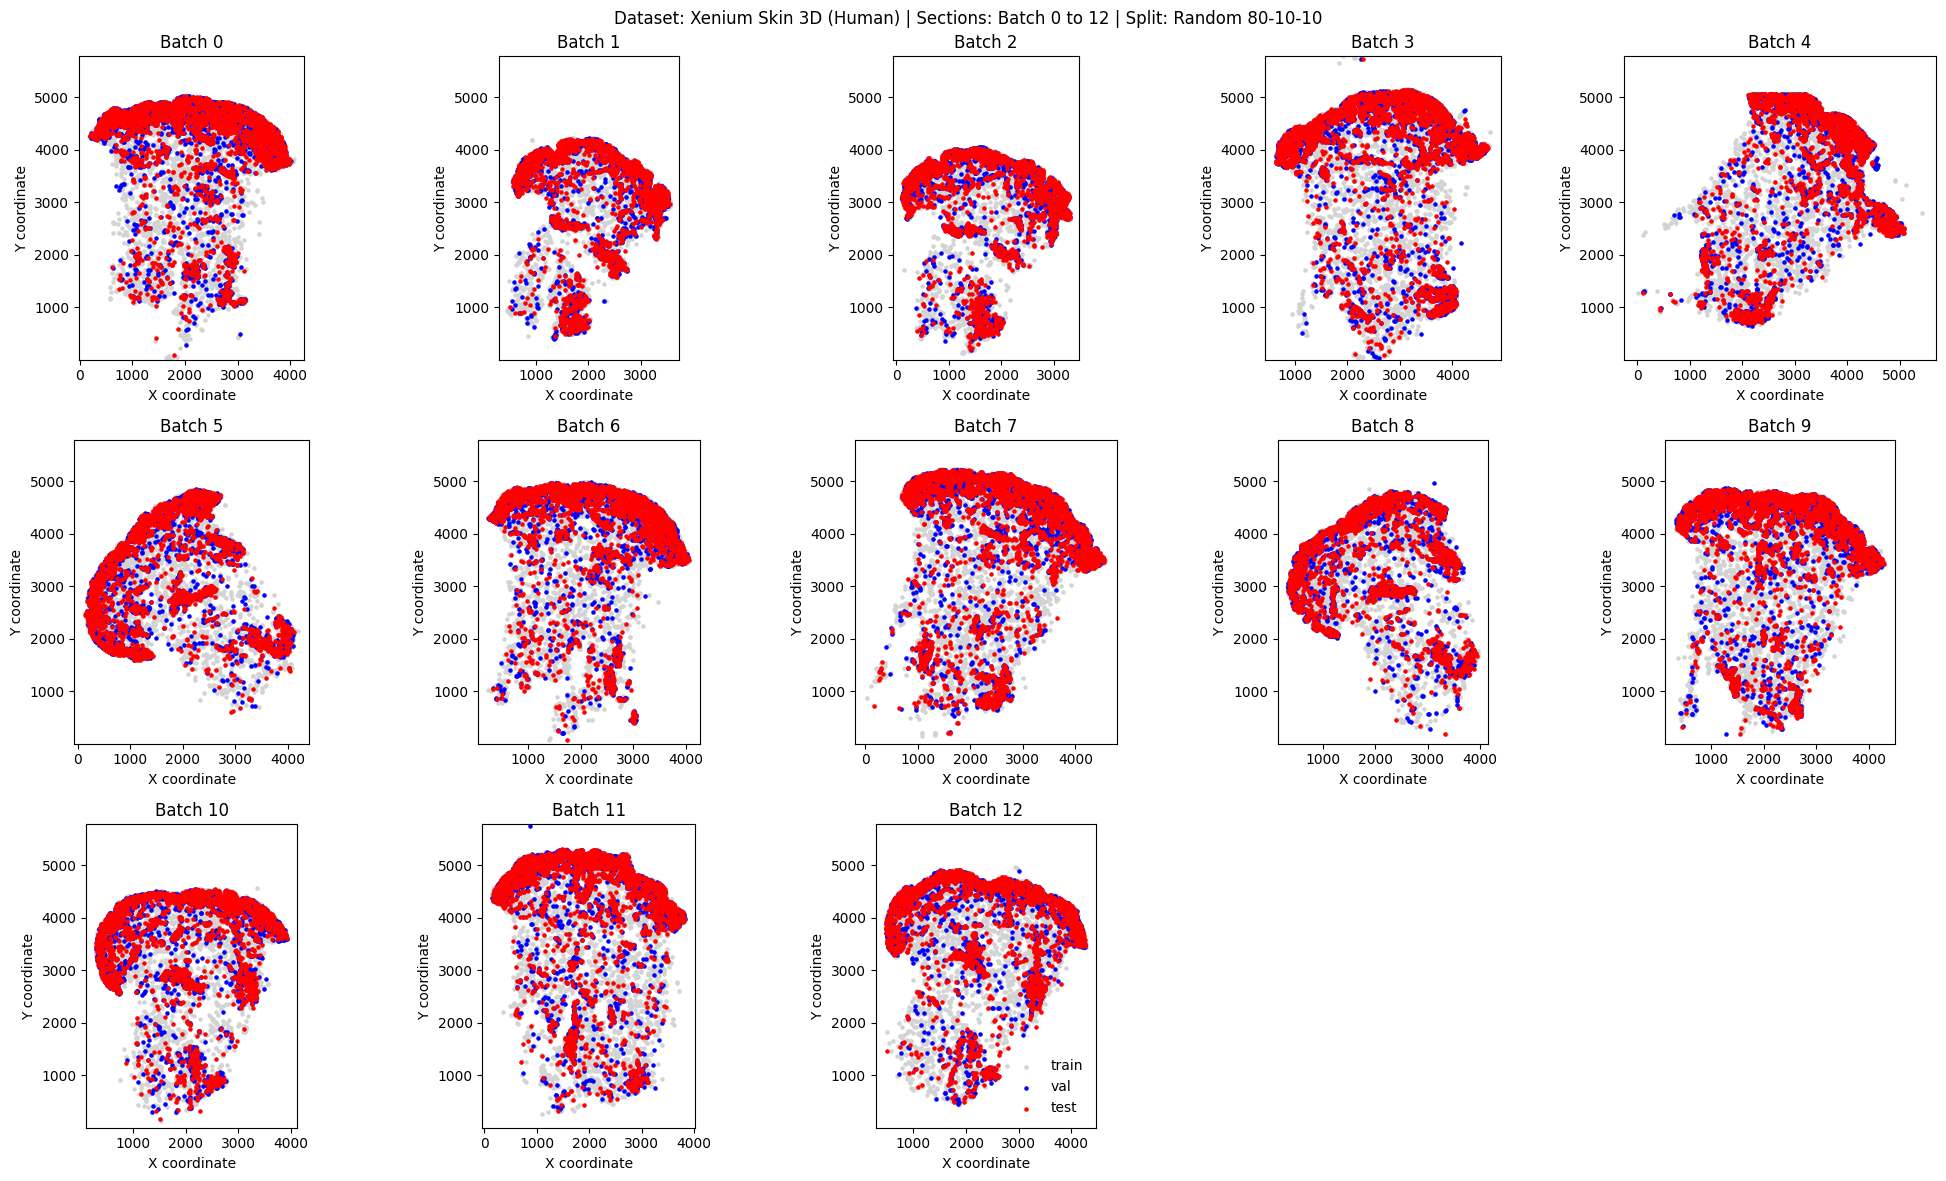

In [9]:
multiple_sections_train_val_test_splits(
    data_batch=xhs1021_15b_1p_rdn_data_batch,
    title='Dataset: Xenium Skin 3D (Human) | Sections: Batch 0 to 12 | Split: Random 80-10-10',
    height=4,
    width=4,
    xlim=-1
)

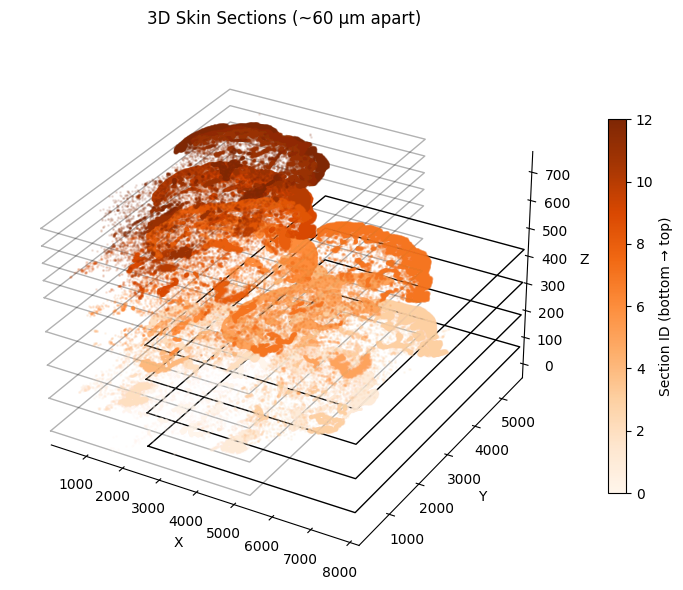

<Figure size 640x480 with 0 Axes>

In [17]:
stack_sections_3d(
    xhs1021_15b_1p_3_test_patch_data_batch,
    spacing_microns=60,
    title="3D Skin Sections (~60 µm apart)",
    alpha=0.1,
    highlight_sections_1based=(2,4,6,8),   # human indexing
    offset_factor=0.005,                        # fraction of global width to shift
    highlight_bbox_lw=1.0,
    normal_bbox_lw=1,
    normal_bbox_alpha=0.3
)


## Cell-wise Imputation for top 5 genes

In [19]:
adata_fname = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1021-15b_1p/sweep/VQNiche/batch=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]/spatial_n_neighs_8/seed/20250924-082526/wandb/offline-run-20250924_082526-7qrfoprj/results/epoch=3-train_pearson_1hop_nbr=0.81/predict_adata.pkl"

with open(adata_fname, "rb") as f:
    adata = pickle.load(f)

adata

AnnData object with n_obs × n_vars = 279849 × 1000
    obs: 'cell_types', 'adata_batch_ids'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'

In [23]:
adata.uns['X_hat'].sum(1)

tensor([585.6606, 585.6606, 585.6606,  ..., 585.6606, 585.6606, 585.6606])

In [ ]:
cell_correlations = pearson_correlation(
        X=adata.uns['X'],
        X_hat=adata.uns['X_hat'],
        compare_genes=False,
        mean=False
)

In [37]:
cell_correlations.shape

(279849,)

In [ ]:
cell_correlations = pearson_correlation(
        X=adata.uns['X'],
        X_hat=adata.uns['X_hat'],
        compare_genes=False,
        mean=False
)

In [39]:
np.array(adata.obs['adata_batch_ids']).shape

(279849,)

In [45]:
hop_gene_correlations = pearson_correlation(
        X=adata.uns['X_nbr'],
        X_hat=adata.uns['X_hat_nbr'],
        compare_genes=True,
        mean=False
)

In [46]:
sort_idx = np.argsort(hop_gene_correlations)

In [51]:
# hop_gene_correlations[sort_idx][:5]
print(hop_gene_correlations[sort_idx][-5:])
print(sort_idx[-5:])

[0.8775269  0.88192683 0.8822992  0.8825933  0.9051935 ]
[ 64 839 170 405 826]


In [41]:
df = pd.DataFrame({'PC':cell_correlations, 'Z-level':np.array(adata.obs['adata_batch_ids'])})
display(df.head(3))

,PC,Z-level
0,0.650413,0
1,0.243093,0
2,0.660361,0


In [ ]:
hop_gene_corr = pearson_correlation(
        X=adata.uns['X_nbr'],
        X_hat=adata.uns['X_hat_nbr'],
        compare_genes=True,
        mean=False
)

In [52]:
# Convert numpy arrays from AnnData
X = adata.uns['X']              # shape: (n_cells, n_genes)
X_nbr = adata.uns['X_nbr']
X_hat = adata.uns['X_hat']
X_hat_nbr = adata.uns['X_hat_nbr']  # careful: earlier you repeated X_nbr
tokens = adata.uns['Indices']
z_levels = np.array(adata.obs['adata_batch_ids'])

# Build dataframes with prefixed column names
df_X = pd.DataFrame(X, columns=[f"X_{i}" for i in range(X.shape[1])])
df_X_nbr = pd.DataFrame(X_nbr, columns=[f"X_nbr_{i}" for i in range(X_nbr.shape[1])])
df_X_hat = pd.DataFrame(X_hat, columns=[f"X_hat_{i}" for i in range(X_hat.shape[1])])
df_X_hat_nbr = pd.DataFrame(X_hat_nbr, columns=[f"X_hat_nbr_{i}" for i in range(X_hat_nbr.shape[1])])

# Concatenate with metadata
df = pd.concat([df_X, df_X_nbr, df_X_hat, df_X_hat_nbr], axis=1)
df['Token'] = tokens
df['Z_level'] = z_levels

# Preview
print(df.shape)

(279849, 4002)


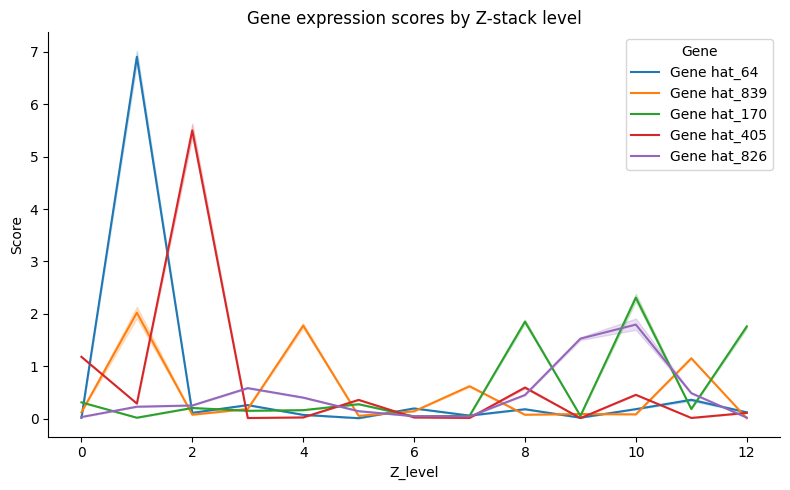

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- select genes of interest (0-indexed) ---
gene_indices = [64, 839, 170, 405, 826]
gene_cols = [f"X_hat_{i}" for i in gene_indices]  # or pick from X_hat, etc.

# --- subset dataframe to those genes + metadata ---
df_sel = df[gene_cols + ["Z_level"]].copy()

# --- reshape to long format for seaborn ---
df_long = df_sel.melt(
    id_vars="Z_level",
    value_vars=gene_cols,
    var_name="Gene",
    value_name="Score"
)

# optional: cleaner gene labels
df_long["Gene"] = df_long["Gene"].str.replace("X_", "Gene ")

# --- plot ---
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_long,
    x="Z_level",
    y="Score",
    hue="Gene"
)
sns.despine()
plt.title("Gene expression scores by Z-stack level")
plt.tight_layout()
plt.show()


In [59]:
df_sel = df[gene_cols + ["Z_level"]].copy()
df_sel.head(3)

,X_64,X_839,X_170,X_405,X_826,Z_level
0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0


Top 5 genes by mean (ascending):
X_hat_236    2.214894
X_hat_963    2.402717
X_hat_303    2.686913
X_hat_933    2.950076
X_hat_928    2.954435
dtype: float32


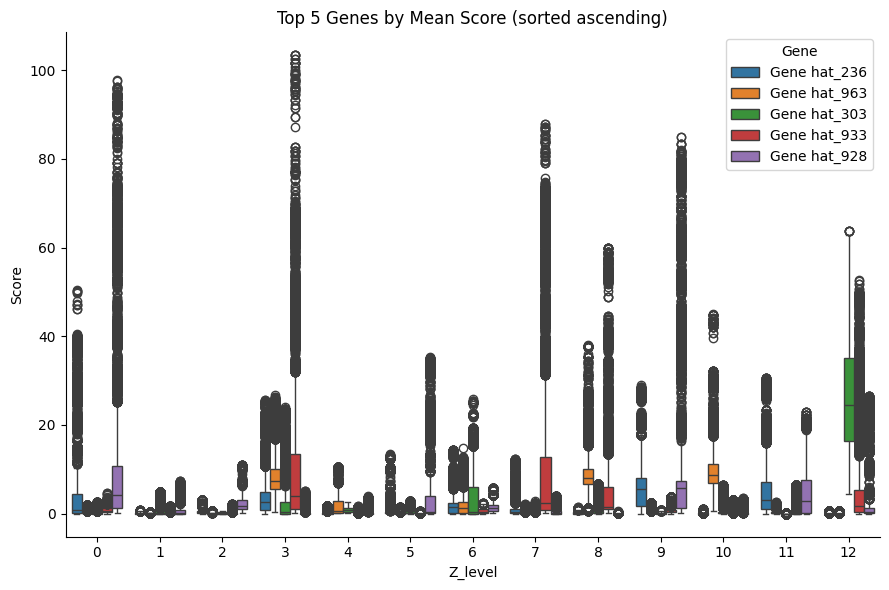

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: select X_ gene columns
x_cols = [c for c in df.columns if c.startswith("X_")]

# --- Step 2: compute mean across cells
gene_means = df[x_cols].mean(axis=0)

# --- Step 3: pick top 5 by mean
top5_genes = gene_means.nlargest(5)

# --- Step 4: sort ascending
top5_genes = top5_genes.sort_values(ascending=True)
print("Top 5 genes by mean (ascending):")
print(top5_genes)

# --- Step 5: reshape dataframe for plotting
df_long = df[top5_genes.index.tolist() + ["Z_level"]].melt(
    id_vars="Z_level",
    value_vars=top5_genes.index,
    var_name="Gene",
    value_name="Score"
)

# optional: cleaner labels
df_long["Gene"] = df_long["Gene"].str.replace("X_", "Gene ")

# --- Step 6: plot
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df_long,
    x="Z_level",
    y="Score",
    hue="Gene"
)
sns.despine()
plt.title("Top 5 Genes by Mean Score (sorted ascending)")
plt.tight_layout()
plt.show()


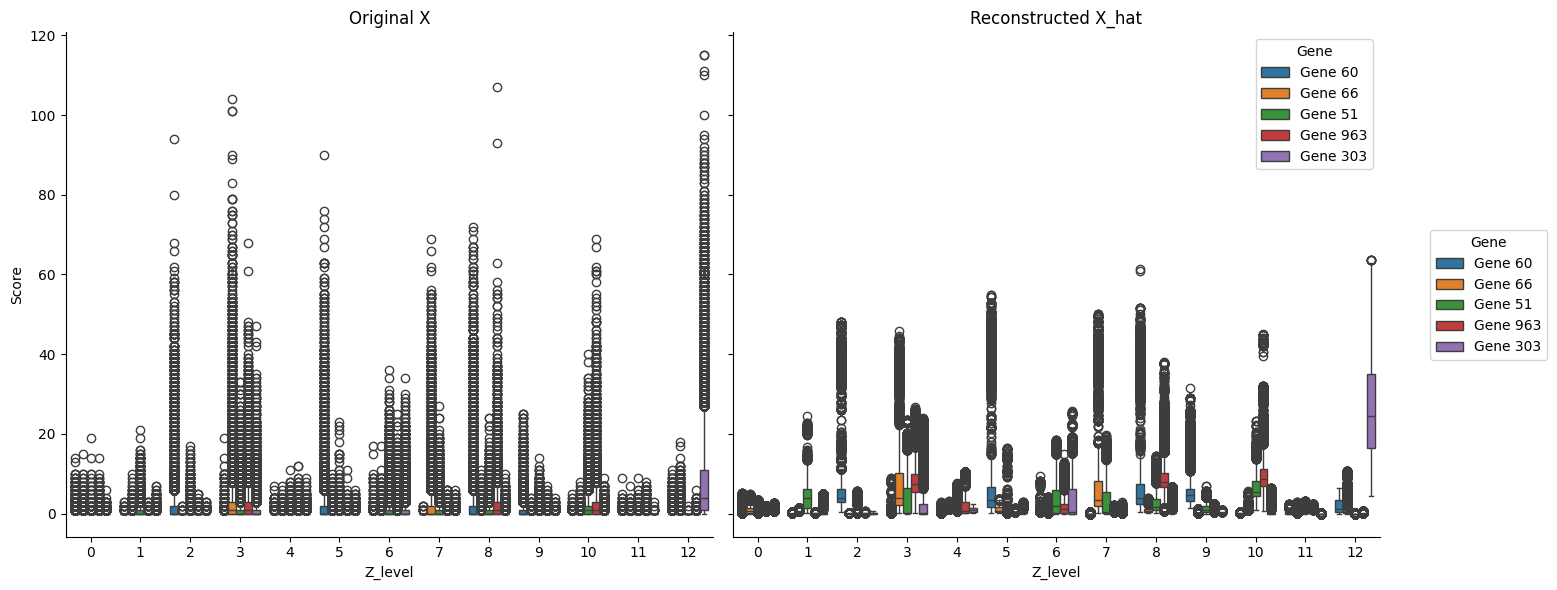

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1) Pick top-5 genes by mean from X_ only (not X_hat_, X_nbr_, etc.) ---
x_cols = [c for c in df.columns
          if c.startswith("X_")
          and not c.startswith("X_hat_")
          and not c.startswith("X_nbr_")
          and not c.startswith("X_hat_nbr_")]

gene_means = df[x_cols].mean(axis=0)
top5 = gene_means.nlargest(5).sort_values(ascending=True)   # keep ascending order
top5_ids = [c.split("_")[-1] for c in top5.index]           # extract numeric ids as strings

# --- 2) Build corresponding column names explicitly to avoid double 'hat' ---
top5_X_cols = [f"X_{i}" for i in top5_ids]
top5_Xhat_cols = [f"X_hat_{i}" for i in top5_ids]

# (optional) guard: keep only those that actually exist
missing_hat = [c for c in top5_Xhat_cols if c not in df.columns]
if missing_hat:
    print("Warning: missing in dataframe:", missing_hat)
    top5_Xhat_cols = [c for c in top5_Xhat_cols if c in df.columns]

# --- 3) Melt for plotting ---
df_long_X = df[top5_X_cols + ["Z_level"]].melt(
    id_vars="Z_level",
    value_vars=top5_X_cols,
    var_name="Gene",
    value_name="Score"
)
df_long_X["Gene"] = df_long_X["Gene"].str.replace("^X_", "Gene ", regex=True)

df_long_Xhat = df[top5_Xhat_cols + ["Z_level"]].melt(
    id_vars="Z_level",
    value_vars=top5_Xhat_cols,
    var_name="Gene",
    value_name="Score"
)
df_long_Xhat["Gene"] = df_long_Xhat["Gene"].str.replace("^X_hat_", "Gene ", regex=True)

# --- 4) Plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.boxplot(data=df_long_X, x="Z_level", y="Score", hue="Gene", ax=axes[0])
axes[0].set_title("Original X")
axes[0].legend_.remove()

sns.boxplot(data=df_long_Xhat, x="Z_level", y="Score", hue="Gene", ax=axes[1])
axes[1].set_title("Reconstructed X_hat")

# one shared legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="Gene", bbox_to_anchor=(1.02, 0.5), loc="center left")

sns.despine()
plt.tight_layout()
plt.show()


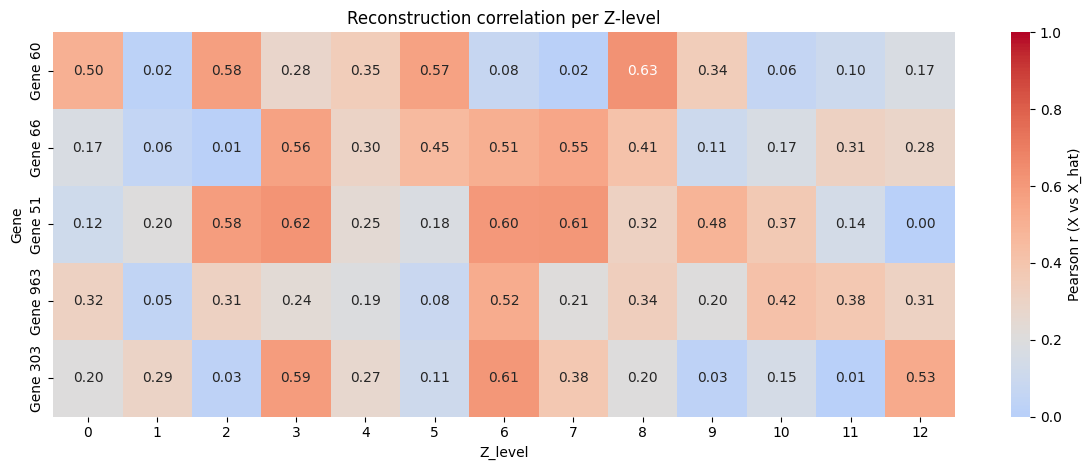

In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- pick top-5 genes by mean X ---
x_cols = [c for c in df.columns
          if c.startswith("X_")
          and not c.startswith(("X_hat_", "X_nbr_", "X_hat_nbr_"))]
top5 = df[x_cols].mean(0).nlargest(5).sort_values(ascending=True)
gene_ids = [c.split("_")[-1] for c in top5.index]  # e.g. ["64","839",...]

# --- compute per-Z_level correlations between X_g and X_hat_g ---
z_levels = sorted(df["Z_level"].unique())
heat = pd.DataFrame(index=[f"Gene {g}" for g in gene_ids], columns=z_levels, dtype=float)

for gid in gene_ids:
    x_col = f"X_{gid}"
    xh_col = f"X_hat_{gid}"
    if xh_col not in df.columns:  # skip if missing
        continue
    for z in z_levels:
        block = df.loc[df["Z_level"] == z, [x_col, xh_col]].dropna()
        # Need at least 2 non-constant points to compute Pearson r
        if len(block) >= 2 and not np.all(block[x_col].values == block[x_col].values[0]) \
                           and not np.all(block[xh_col].values == block[xh_col].values[0]):
            r, _ = pearsonr(block[x_col].values, block[xh_col].values)
        else:
            r = np.nan
        heat.loc[f"Gene {gid}", z] = r

# --- plot heatmap ---
plt.figure(figsize=(12, 4.8))
sns.heatmap(
    heat.astype(float),
    annot=True, fmt=".2f",
    cmap="coolwarm", vmin=0, vmax=1, center=0.2,
    cbar_kws={"label": "Pearson r (X vs X_hat)"}
)
plt.xlabel("Z_level")
plt.ylabel("Gene")
plt.title("Reconstruction correlation per Z-level")
plt.tight_layout()
plt.show()


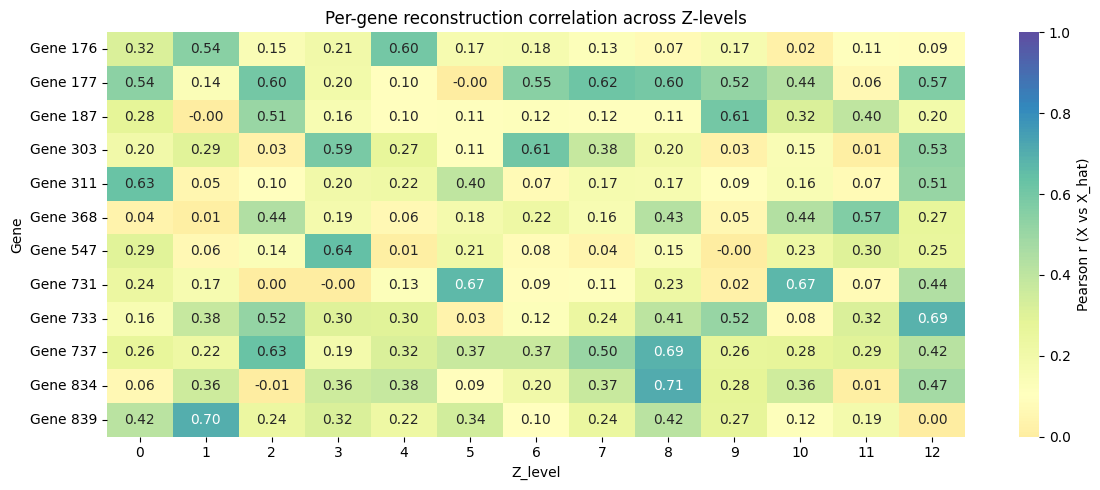

In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- pick the gene set to show ------------------------------------
# Option A: genes that were "best" at least once (from df_best)
# df_best has columns ["Z_level","BestGene","BestCorr"] with BestGene like "Gene 123"
top_gene_ids = sorted({g.split()[-1] for g in df_best["BestGene"]})

# # Option B (alternative): the top-5-by-mean in X from earlier
# x_cols = [c for c in df.columns if c.startswith("X_") and not c.startswith(("X_hat_","X_nbr_","X_hat_nbr_"))]
# top5 = df[x_cols].mean(0).nlargest(5)
# top_gene_ids = [c.split("_")[-1] for c in top5.index]

# --- compute correlations for these genes across all Z-levels -----
z_levels = sorted(df["Z_level"].unique())
heat = pd.DataFrame(index=[f"Gene {g}" for g in top_gene_ids], columns=z_levels, dtype=float)

for gid in top_gene_ids:
    x_col, xh_col = f"X_{gid}", f"X_hat_{gid}"
    if xh_col not in df.columns or x_col not in df.columns:
        continue
    for z in z_levels:
        block = df.loc[df["Z_level"] == z, [x_col, xh_col]].dropna()
        # need ≥2 points and non-constant to compute Pearson r
        if len(block) >= 2 and not np.all(block[x_col].values == block[x_col].values[0]) \
                           and not np.all(block[xh_col].values == block[xh_col].values[0]):
            r, _ = pearsonr(block[x_col].values, block[xh_col].values)
        else:
            r = np.nan
        heat.loc[f"Gene {gid}", z] = r

# --- plot full heatmap --------------------------------------------
plt.figure(figsize=(12, 5))
sns.heatmap(
    heat.astype(float),
    annot=True, fmt=".2f",
    cmap="Spectral", vmin=0, vmax=1, center=0.1,
    cbar_kws={"label": "Pearson r (X vs X_hat)"}
)
plt.title("Per-gene reconstruction correlation across Z-levels")
plt.xlabel("Z_level")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()


In [63]:
hop_gene_corr = pearson_correlation(
        X=adata.uns['X_nbr'],
        X_hat=adata.uns['X_hat_nbr'],
        compare_genes=True,
        mean=False
)

In [64]:
hop_gene_corr.shape

(1000,)

In [ ]:
adata.obs['cell_types']

In [117]:
# Convert numpy arrays from AnnData
X = adata.uns['X']              # shape: (n_cells, n_genes)
X_nbr = adata.uns['X_nbr']
X_hat = adata.uns['X_hat']
X_hat_nbr = adata.uns['X_hat_nbr']  # careful: earlier you repeated X_nbr
tokens = adata.uns['Indices']
z_levels = np.array(adata.obs['adata_batch_ids'])

# Build dataframes with prefixed column names
df_X = pd.DataFrame(X, columns=[f"X_{i}" for i in range(X.shape[1])])
df_X_nbr = pd.DataFrame(X_nbr, columns=[f"X_nbr_{i}" for i in range(X_nbr.shape[1])])
df_X_hat = pd.DataFrame(X_hat, columns=[f"X_hat_{i}" for i in range(X_hat.shape[1])])
df_X_hat_nbr = pd.DataFrame(X_hat_nbr, columns=[f"X_hat_nbr_{i}" for i in range(X_hat_nbr.shape[1])])

# Concatenate with metadata
df = pd.concat([df_X, df_X_nbr, df_X_hat, df_X_hat_nbr], axis=1)
df['Token'] = tokens
df['Z_level'] = z_levels
df['x_coord'] = adata.obsm['spatial'][:,0]
df['y_coord'] = adata.obsm['spatial'][:,1]
df['cell_types'] = adata.obs['cell_types']
# Preview
print(df.shape)


(279849, 4005)


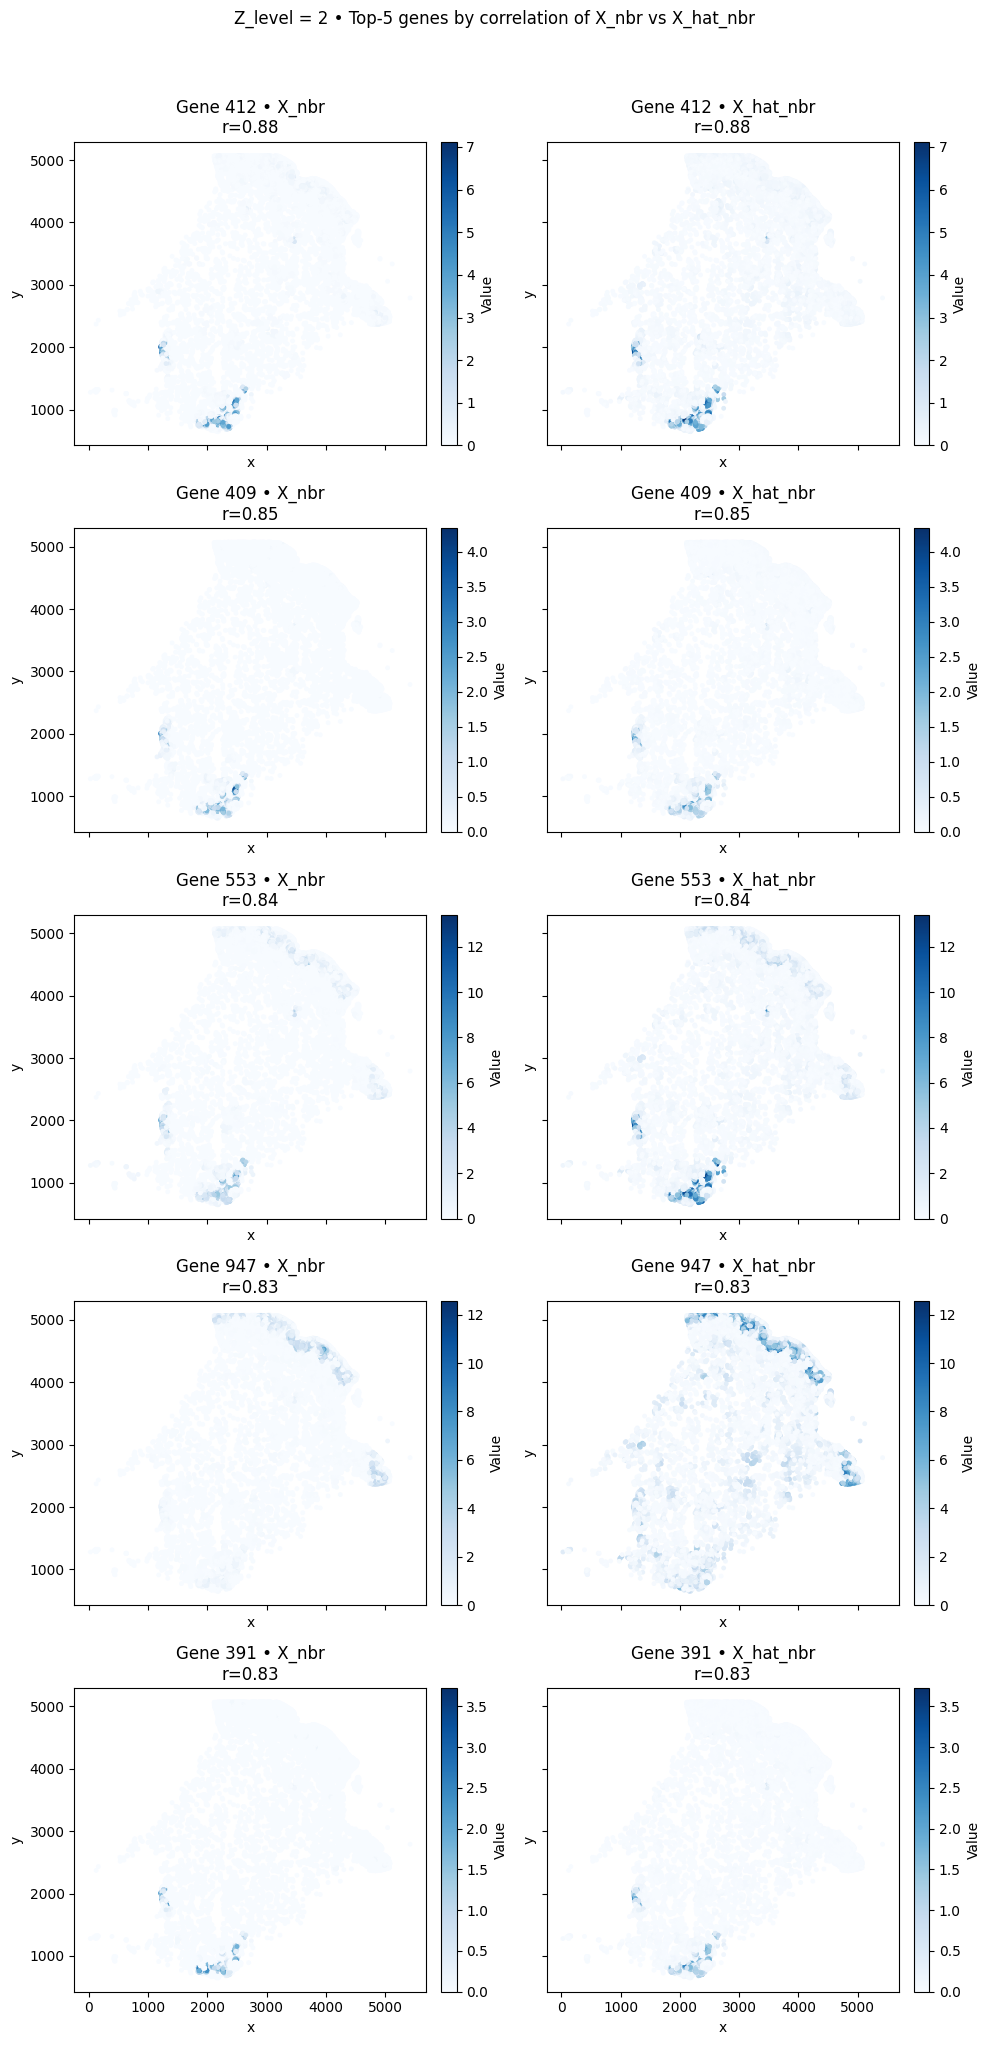

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- 1) subset to Z_level == 2 ---
df2 = df[df["Z_level"] == 4].copy()

# --- 2) find genes present in both X_nbr_ and X_hat_nbr_ ---
nbr_cols = {c for c in df2.columns if c.startswith("X_nbr_")}
hat_nbr_cols = {c for c in df2.columns if c.startswith("X_hat_nbr_")}
gene_ids = sorted(
    {c.split("_")[-1] for c in nbr_cols}
    .intersection({c.split("_")[-1] for c in hat_nbr_cols}),
    key=lambda x: int(x)
)

# --- 3) compute correlations per gene (within Z=2) ---
corrs = []
for gid in gene_ids:
    a = df2[f"X_nbr_{gid}"].to_numpy()
    b = df2[f"X_hat_nbr_{gid}"].to_numpy()
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    if a.size >= 2 and not np.all(a == a[0]) and not np.all(b == b[0]):
        r, _ = pearsonr(a, b)
    else:
        r = np.nan
    corrs.append((gid, r))

corr_df = pd.DataFrame(corrs, columns=["gene_id", "corr"]).dropna()
top5 = corr_df.sort_values("corr", ascending=False).head(5)["gene_id"].tolist()
top5 = [687, 830, 64, 818, 71]

if len(top5) == 0:
    raise ValueError("No genes had a valid correlation at Z_level==2.")

# --- 4) plotting: 5 x 2 grid, left=X_nbr, right=X_hat_nbr for each gene ---
fig, axes = plt.subplots(nrows=len(top5), ncols=2, figsize=(10, 20), sharex=True, sharey=True)
if len(top5) == 1:
    axes = np.array([axes])  # keep 2D shape

for row, gid in enumerate(top5):
    x = df2["x_coord"].to_numpy()
    y = df2["y_coord"].to_numpy()
    v1 = df2[f"X_nbr_{gid}"].to_numpy()
    v2 = df2[f"X_hat_nbr_{gid}"].to_numpy()

    # same color scale within a gene for fair comparison
    vmin = np.nanmin([np.nanmin(v1), np.nanmin(v2)])
    vmax = np.nanmax([np.nanmax(v1), np.nanmax(v2)])

    # correlation value for title
    r = corr_df.loc[corr_df["gene_id"] == gid, "corr"].values[0]
    title_left = f"Gene {gid} • X_nbr\nr={r:.2f}"
    title_right = f"Gene {gid} • X_hat_nbr\nr={r:.2f}"

    sc1 = axes[row, 0].scatter(x, y, c=v1, s=6, cmap="Blues", vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(title_left)
    axes[row, 0].set_xlabel("x"); axes[row, 0].set_ylabel("y")
    cb1 = fig.colorbar(sc1, ax=axes[row, 0], fraction=0.046, pad=0.04)
    cb1.set_label("Value")

    sc2 = axes[row, 1].scatter(x, y, c=v2, s=6, cmap="Blues", vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(title_right)
    axes[row, 1].set_xlabel("x"); axes[row, 1].set_ylabel("y")
    cb2 = fig.colorbar(sc2, ax=axes[row, 1], fraction=0.046, pad=0.04)
    cb2.set_label("Value")

plt.suptitle("Z_level = 2 • Top-5 genes by correlation of X_nbr vs X_hat_nbr", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4087264/2673551738.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


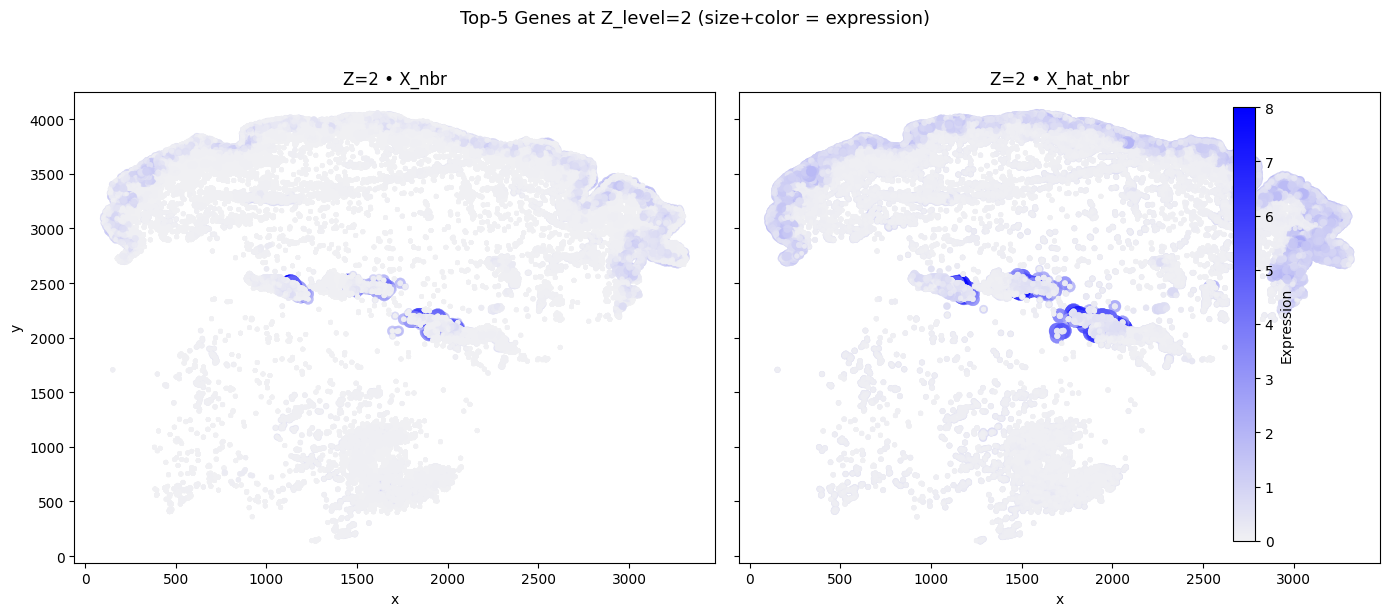

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# we already have df_long with columns: x_coord, y_coord, Gene, X_nbr, X_hat_nbr

# --- set up a blue colormap, where low values are light grey/blue ---
cmap = sns.light_palette("blue", as_cmap=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# --- Left: X_nbr ---
sns.scatterplot(
    data=df_long,
    x="x_coord", y="y_coord",
    hue="X_nbr", size="X_nbr",
    sizes=(10, 200), alpha=0.8,
    palette=cmap, edgecolor=None,
    ax=axes[0], legend=False
)
axes[0].set_title("Z=2 • X_nbr")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

# --- Right: X_hat_nbr ---
sns.scatterplot(
    data=df_long,
    x="x_coord", y="y_coord",
    hue="X_hat_nbr", size="X_hat_nbr",
    sizes=(10, 200), alpha=0.8,
    palette=cmap, edgecolor=None,
    ax=axes[1], legend=False
)
axes[1].set_title("Z=2 • X_hat_nbr")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

# shared colorbar
norm = plt.Normalize(vmin=min(df_long["X_nbr"].min(), df_long["X_hat_nbr"].min()),
                     vmax=max(df_long["X_nbr"].max(), df_long["X_hat_nbr"].max()))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Expression")

plt.suptitle("Top-5 Genes at Z_level=2 (size+color = expression)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


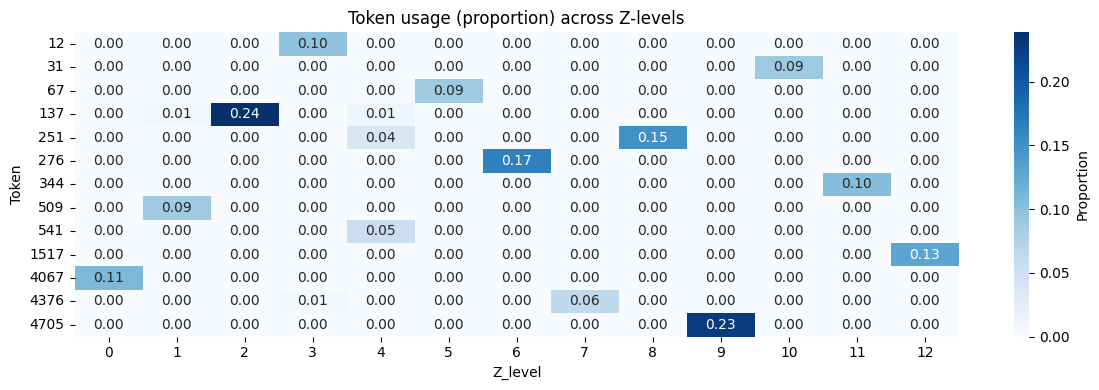

In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure types are clean
df_tok = df[["Z_level", "Token"]].copy()
df_tok["Z_level"] = pd.to_numeric(df_tok["Z_level"], errors="coerce")
df_tok["Token"]   = pd.to_numeric(df_tok["Token"],   errors="coerce")

# 1) counts per (Z_level, Token)
counts = (
    df_tok
    .groupby(["Z_level", "Token"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

# totals per Z_level to get proportions
totals = counts.groupby("Z_level", as_index=False)["count"].sum().rename(columns={"count": "total"})
counts = counts.merge(totals, on="Z_level", how="left")
counts["prop"] = counts["count"] / counts["total"]

# 2) top token per Z_level (by count)
idx = counts.groupby("Z_level")["count"].idxmax()
top_per_level = counts.loc[idx, ["Z_level", "Token"]].rename(columns={"Token": "TopToken"})

# set of winning tokens
winning_tokens = sorted(top_per_level["TopToken"].unique())

# 3) usage of winning tokens across ALL Z_levels (proportions)
win_usage = (
    counts[counts["Token"].isin(winning_tokens)]
    .copy()
)

heat = win_usage.pivot_table(
    index="Token", columns="Z_level", values="prop", fill_value=0.0
).sort_index()

plt.figure(figsize=(12, 4))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="Blues", cbar_kws={"label": "Proportion"})
plt.title("Token usage (proportion) across Z-levels")
plt.xlabel("Z_level"); plt.ylabel("Token")
plt.tight_layout()
plt.show()

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


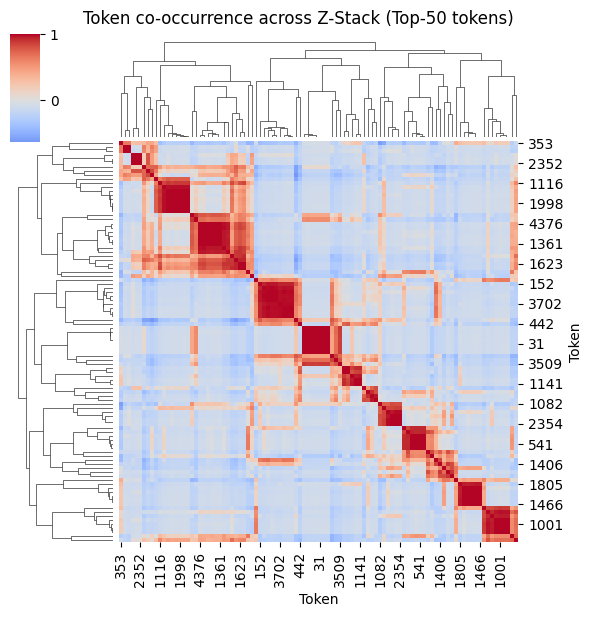

In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# counts: tokens x z_levels
pivot = (
    df.groupby(["Z_level", "Token"])
    .size()
    .unstack(fill_value=0)
)

# pick top-50 tokens overall
top_tokens = pivot.sum(axis=0).nlargest(100).index
pivot = pivot[top_tokens]

# correlation across tokens
corr = pivot.corr()

# heatmap with clustering
sns.clustermap(corr, cmap="coolwarm", center=0, figsize=(6, 6))
plt.suptitle("Token co-occurrence across Z-Stack (Top-50 tokens)", y=1.02)
plt.show()


/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


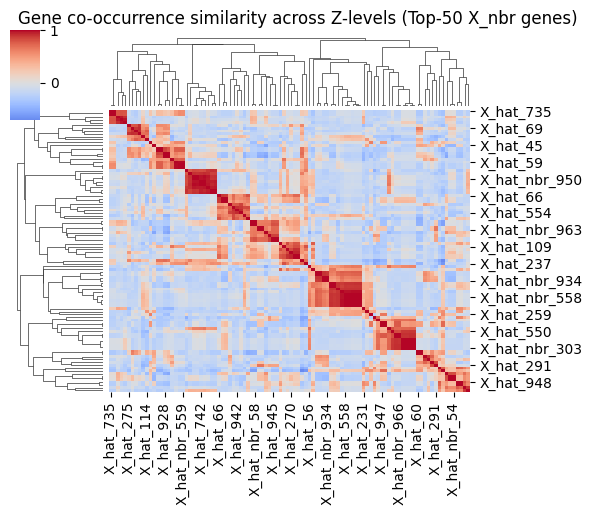

In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1) extract gene nbr columns ---
nbr_cols = [c for c in df.columns if c.startswith("X_")]

# average expression per Z-level
gene_by_level = df.groupby("Z_level")[nbr_cols].mean()

# --- 2) pick top-50 genes by variance across levels ---
variances = gene_by_level.var(axis=0)
top_genes = variances.nlargest(100).index

# --- 3) compute correlations among these genes ---
corr = gene_by_level[top_genes].corr()

# --- 4) clustermap visualization ---
sns.clustermap(
    corr, cmap="coolwarm", center=0, figsize=(6, 5)
)
plt.suptitle("Gene co-occurrence similarity across Z-levels (Top-50 X_nbr genes)", y=1.02)
plt.show()


In [102]:
pivot

Token,4705,137,251,276,440,169,1517,4067,12,344,17,31,67,4376,3383,509,2640,856,992,541,1526,1998,1514,35,1805,3793,723,893,659,355,1147,1161,139,4973,3702,395,1623,1361,41,949,72,134,181,2354,140,989,152,1450,1973,1760
Z_level,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,11,0,34,0,136,501,0,2597,0,0,0,0,0,0,0,0,0,0,6,0,297,0,0,0,823,0,0,0,8,0,13,1,20,0,13,268,0,0,0,0,0,0,820,0,0,0,0,0,0,0
1,0,122,0,0,473,0,0,0,0,0,0,0,0,0,138,1584,643,0,102,46,4,0,0,72,0,7,0,0,91,154,4,0,6,0,0,237,0,0,0,0,0,733,1,911,0,90,162,0,37,0
2,0,4121,0,0,69,0,0,0,0,0,7,0,0,0,86,0,0,1,42,14,392,0,0,17,7,30,0,0,8,6,0,116,2,0,2,361,28,0,0,0,0,111,0,0,508,207,10,14,1,0
3,1,0,1,2,2,0,0,0,2452,1,0,0,0,155,262,0,285,0,2,1,8,1113,507,0,0,12,0,926,20,81,1,110,210,3,0,0,297,0,91,0,0,0,0,0,0,83,0,0,813,0
4,0,246,770,0,133,854,4,1,0,0,240,0,23,0,520,2,200,76,1009,1134,0,15,3,1031,1,47,0,0,11,52,9,0,10,0,5,38,5,0,0,1,6,10,2,0,382,208,2,7,0,0
5,1,20,4,2,723,0,0,0,0,0,1348,0,1862,0,28,0,27,0,0,0,37,0,0,0,0,27,153,0,0,5,281,98,0,0,737,1,1,0,4,17,0,39,0,0,0,1,555,9,0,0
6,10,0,0,3554,0,0,0,0,2,3,0,0,0,0,12,0,1,0,11,0,74,6,237,0,0,30,0,63,0,0,0,170,227,0,1,0,148,1,19,0,0,0,0,0,0,32,0,0,0,0
7,18,0,0,1,46,0,1,0,0,0,13,0,0,1682,494,0,159,1213,0,0,0,21,27,0,0,839,0,40,0,385,33,28,382,958,1,20,457,928,819,0,0,2,0,0,0,71,0,0,0,0
8,0,0,2809,0,600,1398,0,0,0,0,256,5,0,0,5,0,56,0,0,2,2,0,2,0,0,68,361,0,0,17,222,357,4,2,69,4,0,6,0,268,0,24,11,0,0,123,125,311,0,0


/tmp/ipykernel_4087264/4165051466.py:25: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  tok_group_by_level = token_prop[top_tokens].groupby(token_group_profiles["Group"], axis=1).mean()
/tmp/ipykernel_4087264/4165051466.py:41: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  gene_group_by_level = gene_by_level[top_genes].groupby(gene_group_profiles["Group"], axis=1).mean()


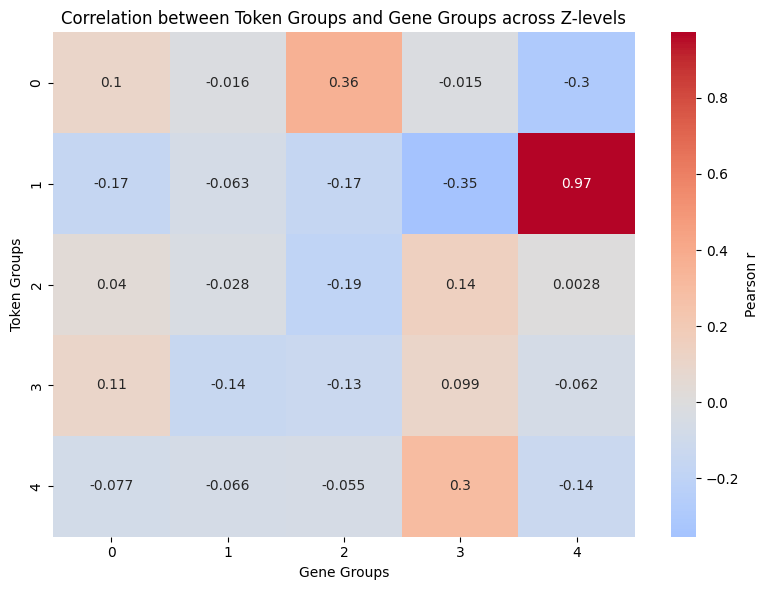

In [115]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- 1) Token usage across levels ---
token_usage = (
    df.groupby(["Z_level", "Token"])
    .size()
    .unstack(fill_value=0)
)
token_prop = token_usage.div(token_usage.sum(axis=1), axis=0)

# cluster top 100 tokens into groups
top_tokens = token_usage.sum().nlargest(100).index
X_tok = token_prop[top_tokens].T
tok_groups = KMeans(n_clusters=5, random_state=0).fit_predict(X_tok)

token_group_profiles = pd.DataFrame({
    "Token": top_tokens,
    "Group": tok_groups
}).set_index("Token")

# aggregate into group profiles across Z-levels
tok_group_by_level = token_prop[top_tokens].groupby(token_group_profiles["Group"], axis=1).mean()

# --- 2) Gene usage across levels ---
nbr_cols = [c for c in df.columns if c.startswith("X_nbr_")]
gene_by_level = df.groupby("Z_level")[nbr_cols].mean()

# cluster top 100 genes into groups
top_genes = gene_by_level.var().nlargest(100).index
X_gene = gene_by_level[top_genes].T
gene_groups = KMeans(n_clusters=5, random_state=0).fit_predict(X_gene)

gene_group_profiles = pd.DataFrame({
    "Gene": top_genes,
    "Group": gene_groups
}).set_index("Gene")

gene_group_by_level = gene_by_level[top_genes].groupby(gene_group_profiles["Group"], axis=1).mean()

# --- 3) Correlation between group profiles ---
# each column = group profile across Z-levels
corr_matrix = pd.DataFrame(index=tok_group_by_level.columns, columns=gene_group_by_level.columns)

for tg in tok_group_by_level.columns:
    for gg in gene_group_by_level.columns:
        corr_matrix.loc[tg, gg] = tok_group_by_level[tg].corr(gene_group_by_level[gg])

corr_matrix = corr_matrix.astype(float)

# --- 4) Heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, cbar_kws={"label":"Pearson r"})
plt.xlabel("Gene Groups")
plt.ylabel("Token Groups")
plt.title("Correlation between Token Groups and Gene Groups across Z-levels")
plt.tight_layout()
plt.show()


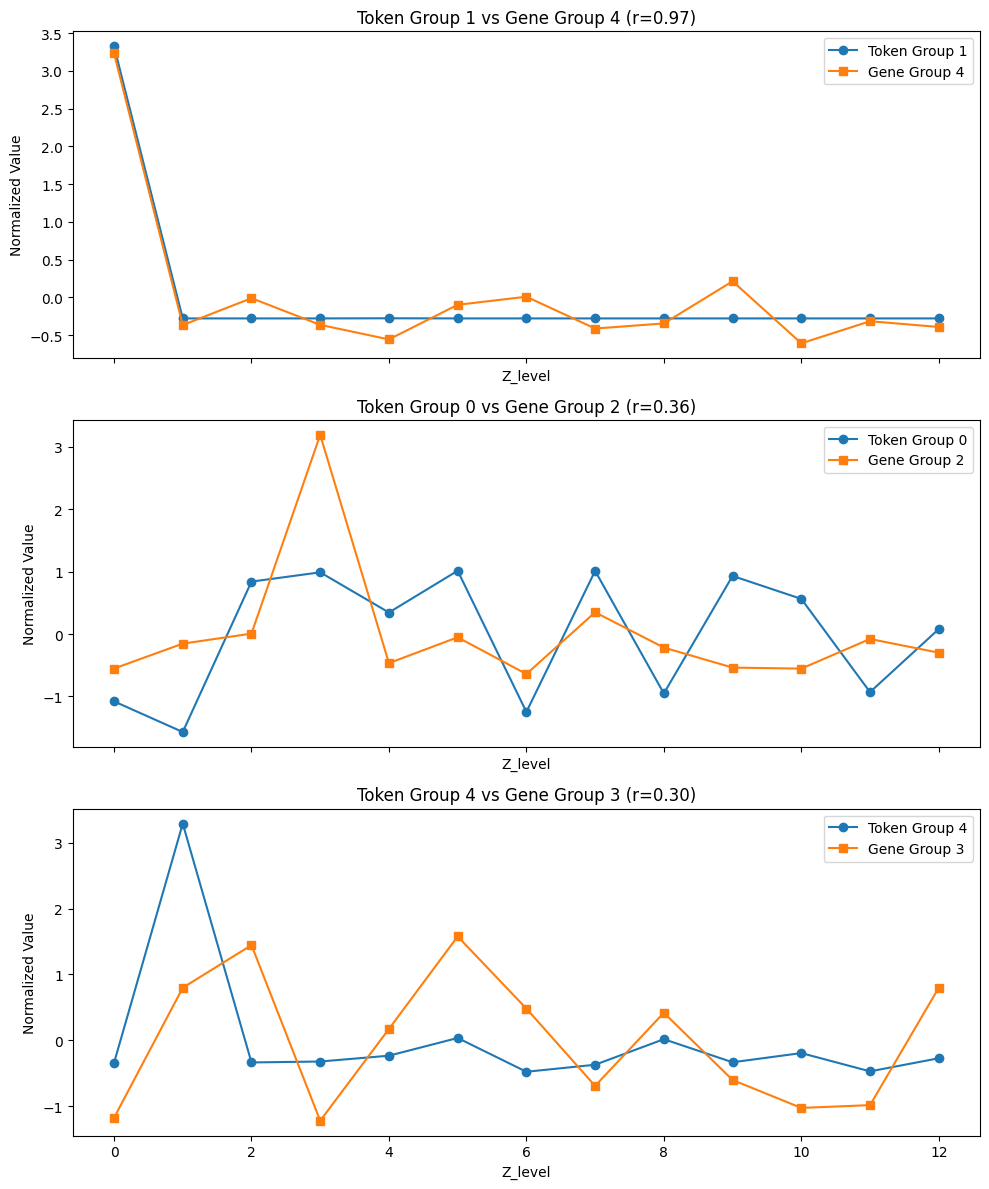

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# assume you already have:
# tok_group_by_level : DataFrame (index = Z_level, columns = token groups)
# gene_group_by_level: DataFrame (index = Z_level, columns = gene groups)
# corr_matrix        : correlations between them

# pick the top 3 strongest correlated pairs
pairs = corr_matrix.stack().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(len(pairs), 1, figsize=(10, 4*len(pairs)), sharex=True)

if len(pairs) == 1:
    axes = [axes]  # make iterable

for ax, (tg, gg) in zip(axes, pairs):
    t_series = tok_group_by_level[tg]
    g_series = gene_group_by_level[gg]
    
    # normalize (z-score) so scales are comparable
    t_norm = (t_series - t_series.mean()) / t_series.std()
    g_norm = (g_series - g_series.mean()) / g_series.std()
    
    ax.plot(t_norm.index, t_norm.values, marker="o", label=f"Token Group {tg}")
    ax.plot(g_norm.index, g_norm.values, marker="s", label=f"Gene Group {gg}")
    ax.set_title(f"Token Group {tg} vs Gene Group {gg} (r={corr_matrix.loc[tg, gg]:.2f})")
    ax.set_xlabel("Z_level")
    ax.set_ylabel("Normalized Value")
    ax.legend()

plt.tight_layout()
plt.show()


In [120]:
df.

(279849, 4005)

In [119]:
# average token profile across Z-levels for each cell type
profiles = []
for ct in df_tok["cell_type"].unique():
    prof = token_profile_for_celltype(ct).mean(axis=0)
    profiles.append(prof.rename(ct))
profiles = pd.DataFrame(profiles).fillna(0)

# keep only top 30 tokens overall
top_tokens = profiles.sum(axis=0).nlargest(30).index
profiles = profiles[top_tokens]

# correlation (cell type × token)
corr = profiles.T.corrwith  # optional, or use seaborn clustermap
sns.clustermap(profiles, cmap="Blues", figsize=(12, 8))
plt.title("Token usage across cell types (averaged over Z-levels)")
plt.show()


KeyError: 'cell_type'

In [87]:
sq.gr.spatial_neighbors(adata)
sq.gr.spatial_autocorr(adata, mode="moran", genes=adata.var_names)

In [89]:
adata.uns["moranI"].head()

,I,pval_norm,var_norm,pval_norm_fdr_bh
687,0.427299,0.0,0.000001,0.0
830,0.424420,0.0,0.000001,0.0
64,0.391761,0.0,0.000001,0.0
818,0.387755,0.0,0.000001,0.0
71,0.386523,0.0,0.000001,0.0


In [ ]:
wandb_run_dir = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1021-15b_1p/sweep/VQNiche/batch=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]/spatial_n_neighs_8/seed/20250924-082526/wandb/offline-run-20250924_082526-7qrfoprj"